# Exploratory Data Analysis
## European Housing Price Forecasting — EU-26 Panel Dataset

**Course:** Machine Learning and Deep Learning, CBS Spring 2026  
**Purpose:** This notebook performs exploratory data analysis on the final modelling panel dataset. It serves two purposes:
1. Provide the descriptive analysis and visualisations required for the project report
2. Inform modelling decisions — feature selection, outlier handling, train/test split, and cluster design


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#e8e8e8",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

PALETTE = "tab20"
ACCENT  = "#2E5496"
RED     = "#C0392B"
GREEN   = "#1A7A4A"

# Load data
# model_data = pd.read_excel("C:\\Users\\carla\\CBS\\ml-final-project\\s1-data-handling\\model_data.xlsx")
#model_data = pd.read_excel("C:\\Users\\ChristophSchilling\\OneDrive - BLAID GmbH\\Dokumente\\GitHub\\ml-final-project\\s1-data-handling\\model_data.xlsx")
model_data = pd.read_excel(r"C:\Users\Giulia\Documents\GitHub\european-house-market-forecasting\model_data.xlsx")
# Ensure quarter is sorted correctly as a string period
model_data = model_data.sort_values(["country_code", "quarter"]).reset_index(drop=True)

print(f"Dataset shape: {model_data.shape}")
print(f"Countries:     {model_data['country_code'].nunique()}")
print(f"Quarter range: {model_data['quarter'].min()} → {model_data['quarter'].max()}")
print(f"Total rows:    {len(model_data):,}")
print(f"Total columns: {len(model_data.columns):,}")

Dataset shape: (1704, 39)
Countries:     26
Quarter range: 2005-Q3 → 2025-Q2
Total rows:    1,704
Total columns: 39


## 1. Dataset Overview

A first look at the structure of the panel: variable types, value ranges, and the overall shape of the data.


In [2]:
# 1.1  Basic info
print("DATA TYPES:")
print(model_data.dtypes.to_string())
print()
print("DESCRIPTIVE STATISTICS (numeric columns):")
print(model_data.describe().round(3).to_string())

DATA TYPES:
country_code                       str
country                            str
quarter                            str
hpi                            float64
hicp_q                         float64
unemployment_rate              float64
gdp_index                      float64
building_permits_index         float64
old_age_dependency_ratio       float64
population_density             float64
mortgage_rate_pct              float64
lt_interest_rate               float64
year                             int64
quarter_num                      int64
eurozone_member_current          int64
eurozone_member_timevarying      int64
hpi_qoq_pct                    float64
hicp_qoq_pct                   float64
gdp_qoq_pct                    float64
permits_qoq_pct                float64
target_hpi_next_q              float64
parliament_rile                float64
hpi_qoq_pct_lag1               float64
hpi_qoq_pct_lag2               float64
hicp_qoq_pct_lag1              float64
hicp_qoq_pct_

OBSERVATIONS PER COUNTRY:
              n_quarters  first_q   last_q
country_code                              
SE                    80  2005-Q3  2025-Q2
FR                    80  2005-Q3  2025-Q2
DK                    65  2009-Q2  2025-Q2
CY                    65  2009-Q2  2025-Q2
CZ                    65  2009-Q2  2025-Q2
DE                    65  2009-Q2  2025-Q2
ES                    65  2009-Q2  2025-Q2
EE                    65  2009-Q2  2025-Q2
BE                    65  2009-Q2  2025-Q2
BG                    65  2009-Q2  2025-Q2
SK                    65  2009-Q2  2025-Q2
FI                    65  2009-Q2  2025-Q2
HU                    65  2009-Q2  2025-Q2
HR                    65  2009-Q2  2025-Q2
LT                    65  2009-Q2  2025-Q2
LU                    65  2009-Q2  2025-Q2
LV                    65  2009-Q2  2025-Q2
IE                    65  2009-Q2  2025-Q2
SI                    65  2009-Q2  2025-Q2
MT                    65  2009-Q2  2025-Q2
PT                    65  20

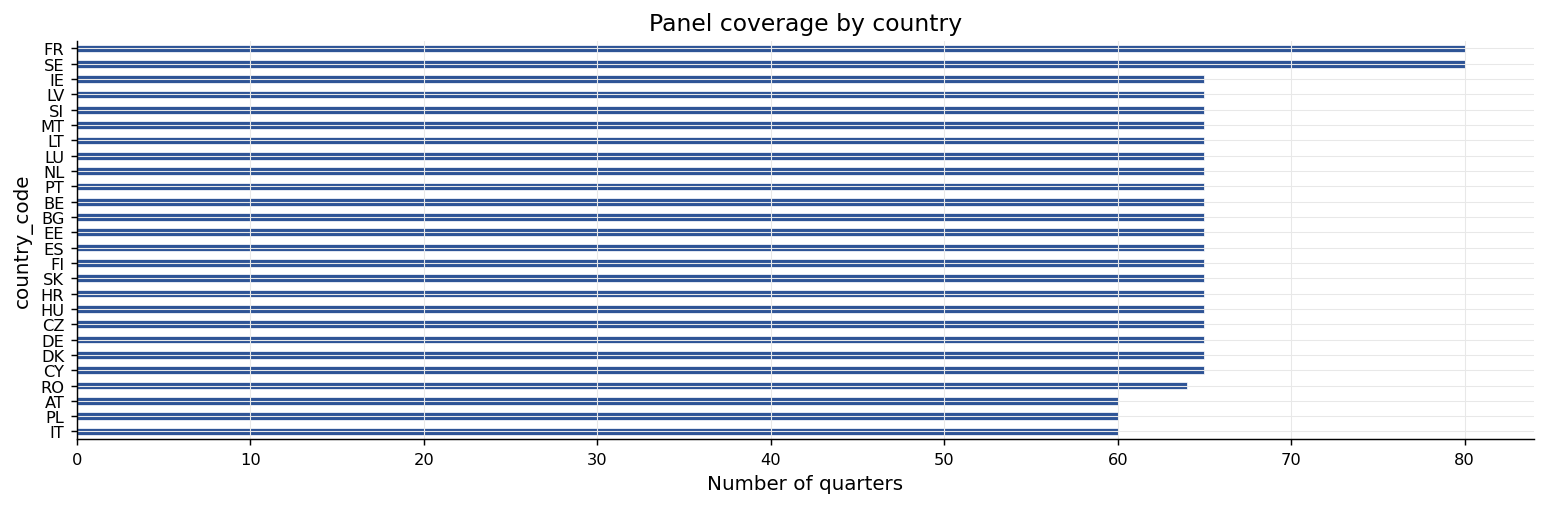

In [3]:
# 1.2  Observation counts per country
obs_per_country = (model_data.groupby("country_code")
                   .agg(n_quarters=("quarter","count"),
                        first_q=("quarter","min"),
                        last_q=("quarter","max"))
                   .sort_values("n_quarters", ascending=False))

print("OBSERVATIONS PER COUNTRY:")
print(obs_per_country.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
obs_per_country["n_quarters"].sort_values().plot(
    kind="barh", ax=ax, color=ACCENT, edgecolor="white", linewidth=0.4)
ax.set_xlabel("Number of quarters")
ax.set_title("Panel coverage by country")
plt.tight_layout()
plt.show()


MISSING VALUE SUMMARY:
mortgage_rate_pct_lag2      33.5
mortgage_rate_pct_lag1      33.1
mortgage_rate_pct           32.9
old_age_dependency_ratio    29.8
population_density          23.7
parliament_rile_lag2         5.4
parliament_rile_lag1         4.8
parliament_rile              4.1
lt_interest_rate_lag2        3.1
lt_interest_rate_lag1        2.6
lt_interest_rate             2.6
unemployment_rate_lag2       1.5
unemployment_qoq_change      1.5
permits_qoq_pct_lag2         0.4
hicp_qoq_pct_lag2            0.4
hpi_qoq_pct_lag2             0.4
gdp_qoq_pct_lag2             0.4


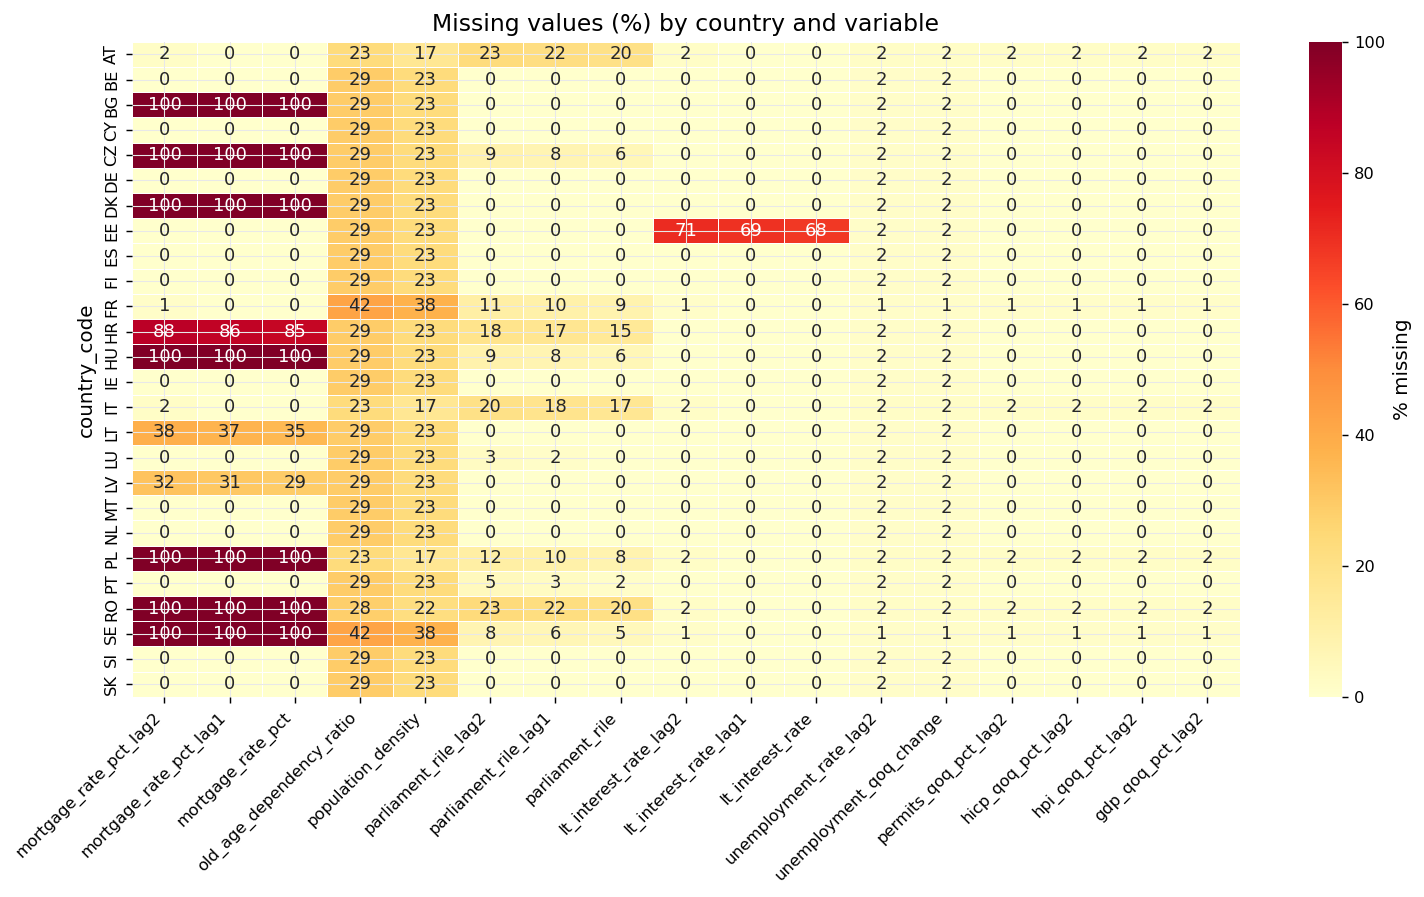

In [4]:
# 1.3  Missing value heatmap
# Shows which variables have missing values, and for which countries
missing_pct = (model_data.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("MISSING VALUE SUMMARY:")
print(missing_pct.round(1).to_string())

# Heatmap: countries × variables with any missingness
miss_cols = missing_pct.index.tolist()
if miss_cols:
    miss_matrix = (model_data.groupby("country_code")[miss_cols]
                   .apply(lambda g: g.isnull().mean() * 100))
    fig, ax = plt.subplots(figsize=(max(10, len(miss_cols)*0.7), 7))
    sns.heatmap(miss_matrix, ax=ax, cmap="YlOrRd", linewidths=0.3,
                annot=True, fmt=".0f", cbar_kws={"label": "% missing"})
    ax.set_title("Missing values (%) by country and variable")
    ax.set_xlabel("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


## 2. Target Variable Deep-Dive

`target_hpi_next_q` is the quarter-on-quarter percentage growth of the house price index in the *following* quarter. This is what every model is trying to predict. Understanding its distribution, temporal behaviour, and cross-country variation is the single most important part of the EDA.


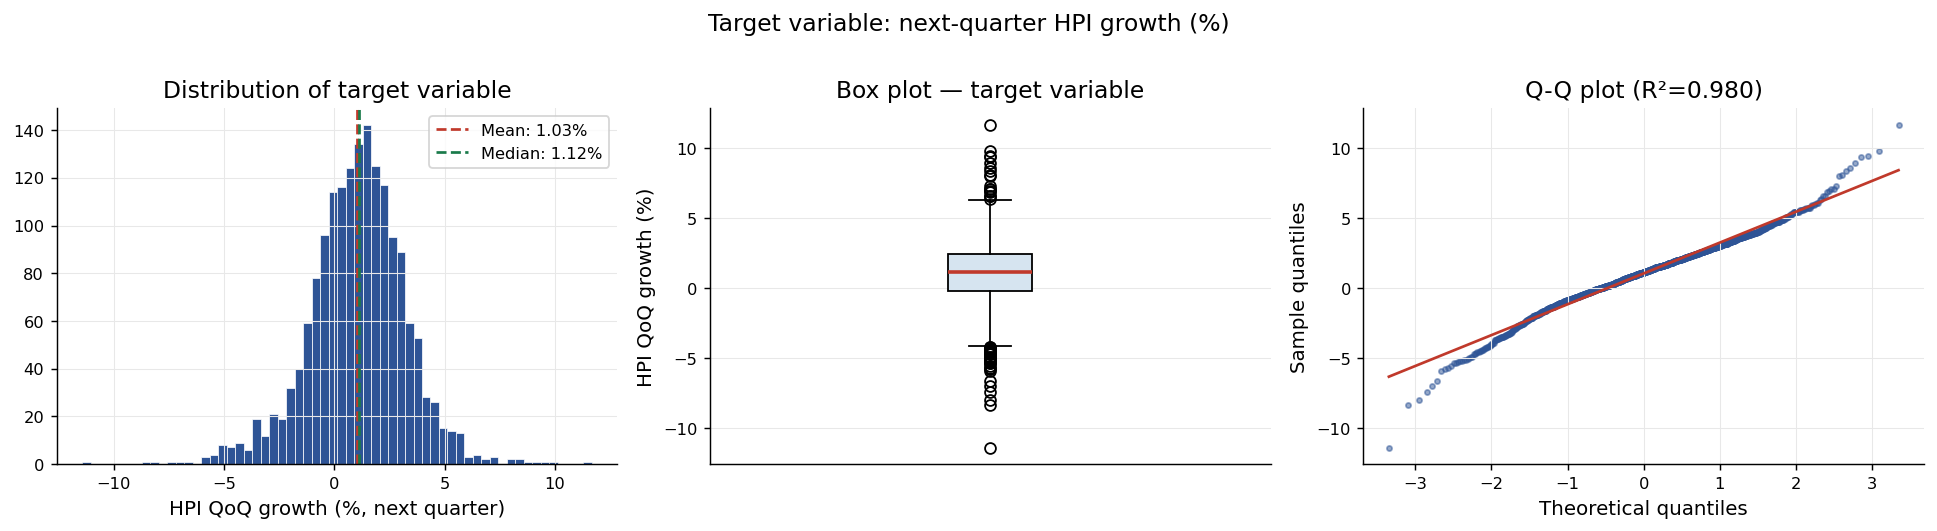

Mean:     1.035%
Std:      2.222%
Skewness: -0.243
Kurtosis: 1.939
Min:      -11.436%
Max:      11.676%
% positive quarters: 70.7%


In [5]:
# 2.1  Distribution of the target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(model_data["target_hpi_next_q"].dropna(), bins=60,
             color=ACCENT, edgecolor="white", linewidth=0.4)
axes[0].axvline(model_data["target_hpi_next_q"].mean(), color=RED,
                linestyle="--", linewidth=1.5, label=f'Mean: {model_data["target_hpi_next_q"].mean():.2f}%')
axes[0].axvline(model_data["target_hpi_next_q"].median(), color=GREEN,
                linestyle="--", linewidth=1.5, label=f'Median: {model_data["target_hpi_next_q"].median():.2f}%')
axes[0].set_xlabel("HPI QoQ growth (%, next quarter)")
axes[0].set_title("Distribution of target variable")
axes[0].legend(fontsize=9)

# Box plot
axes[1].boxplot(model_data["target_hpi_next_q"].dropna(),
                patch_artist=True, boxprops=dict(facecolor="#D6E4F0"),
                medianprops=dict(color=RED, linewidth=2))
axes[1].set_ylabel("HPI QoQ growth (%)")
axes[1].set_title("Box plot — target variable")
axes[1].set_xticks([])

# QQ plot (manual)
from scipy import stats
target_clean = model_data["target_hpi_next_q"].dropna().values
(osm, osr), (slope, intercept, r) = stats.probplot(target_clean, dist="norm")
axes[2].scatter(osm, osr, s=8, alpha=0.5, color=ACCENT)
axes[2].plot(osm, slope * np.array(osm) + intercept, color=RED, linewidth=1.5)
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")
axes[2].set_title(f"Q-Q plot (R²={r**2:.3f})")

plt.suptitle("Target variable: next-quarter HPI growth (%)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Mean:     {model_data['target_hpi_next_q'].mean():.3f}%")
print(f"Std:      {model_data['target_hpi_next_q'].std():.3f}%")
print(f"Skewness: {model_data['target_hpi_next_q'].skew():.3f}")
print(f"Kurtosis: {model_data['target_hpi_next_q'].kurtosis():.3f}")
print(f"Min:      {model_data['target_hpi_next_q'].min():.3f}%")
print(f"Max:      {model_data['target_hpi_next_q'].max():.3f}%")
print(f"% positive quarters: {(model_data['target_hpi_next_q'] > 0).mean()*100:.1f}%")


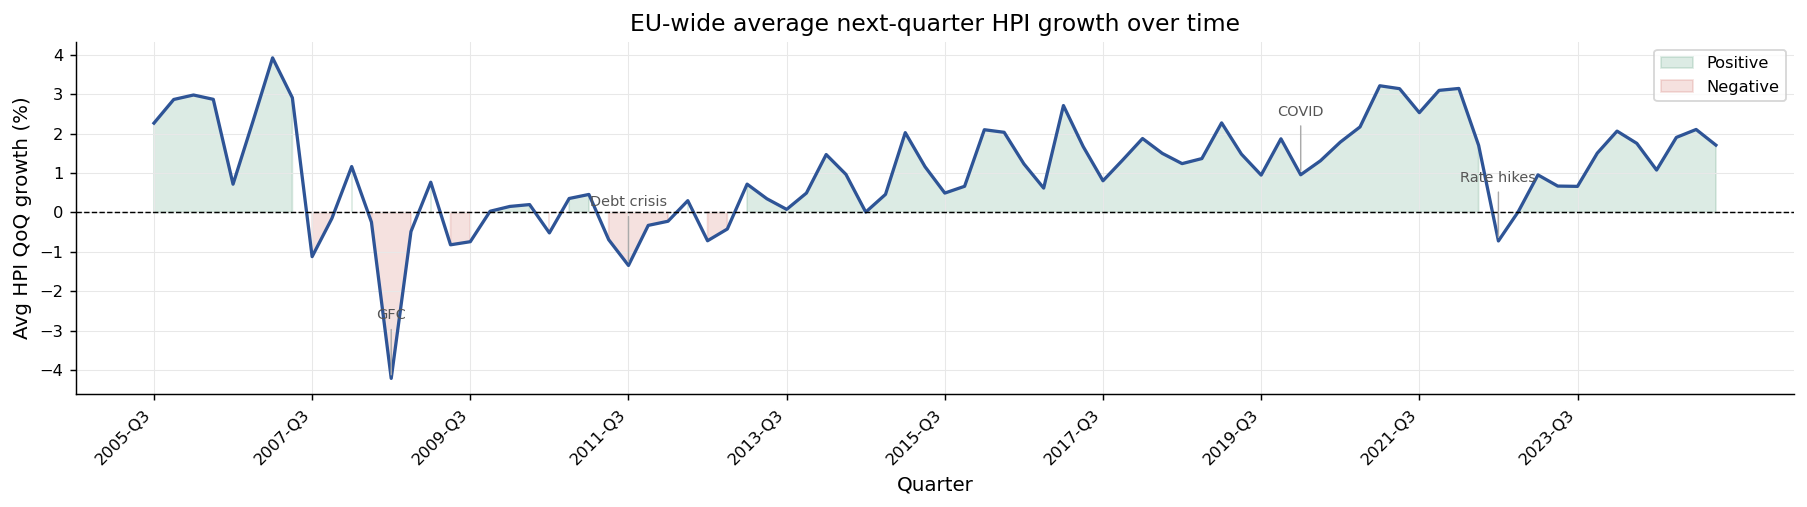

In [6]:
# 2.2  Target over time (EU-wide average)
eu_avg = model_data.groupby("quarter")["target_hpi_next_q"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(eu_avg.index, eu_avg.values, color=ACCENT, linewidth=1.8)
ax.fill_between(eu_avg.index, eu_avg.values, 0,
                where=(eu_avg.values >= 0), alpha=0.15, color=GREEN, label="Positive")
ax.fill_between(eu_avg.index, eu_avg.values, 0,
                where=(eu_avg.values < 0), alpha=0.15, color=RED, label="Negative")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Annotate key episodes
for label, q, offset in [
    ("GFC", "2008-Q3", 1.5),
    ("Debt crisis", "2011-Q3", 1.5),
    ("COVID", "2020-Q1", 1.5),
    ("Rate hikes", "2022-Q3", 1.5),
]:
    if q in eu_avg.index:
        idx = eu_avg.index.get_loc(q)
        ax.annotate(label, xy=(q, eu_avg[q]),
                    xytext=(q, eu_avg[q] + offset),
                    fontsize=8, ha="center", color="#555555",
                    arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.8))

ax.set_xlabel("Quarter")
ax.set_ylabel("Avg HPI QoQ growth (%)")
ax.set_title("EU-wide average next-quarter HPI growth over time")
ax.legend(fontsize=9)

# Show only every 8th tick to avoid clutter
ticks = eu_avg.index[::8]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45, ha="right")
plt.tight_layout()
plt.show()


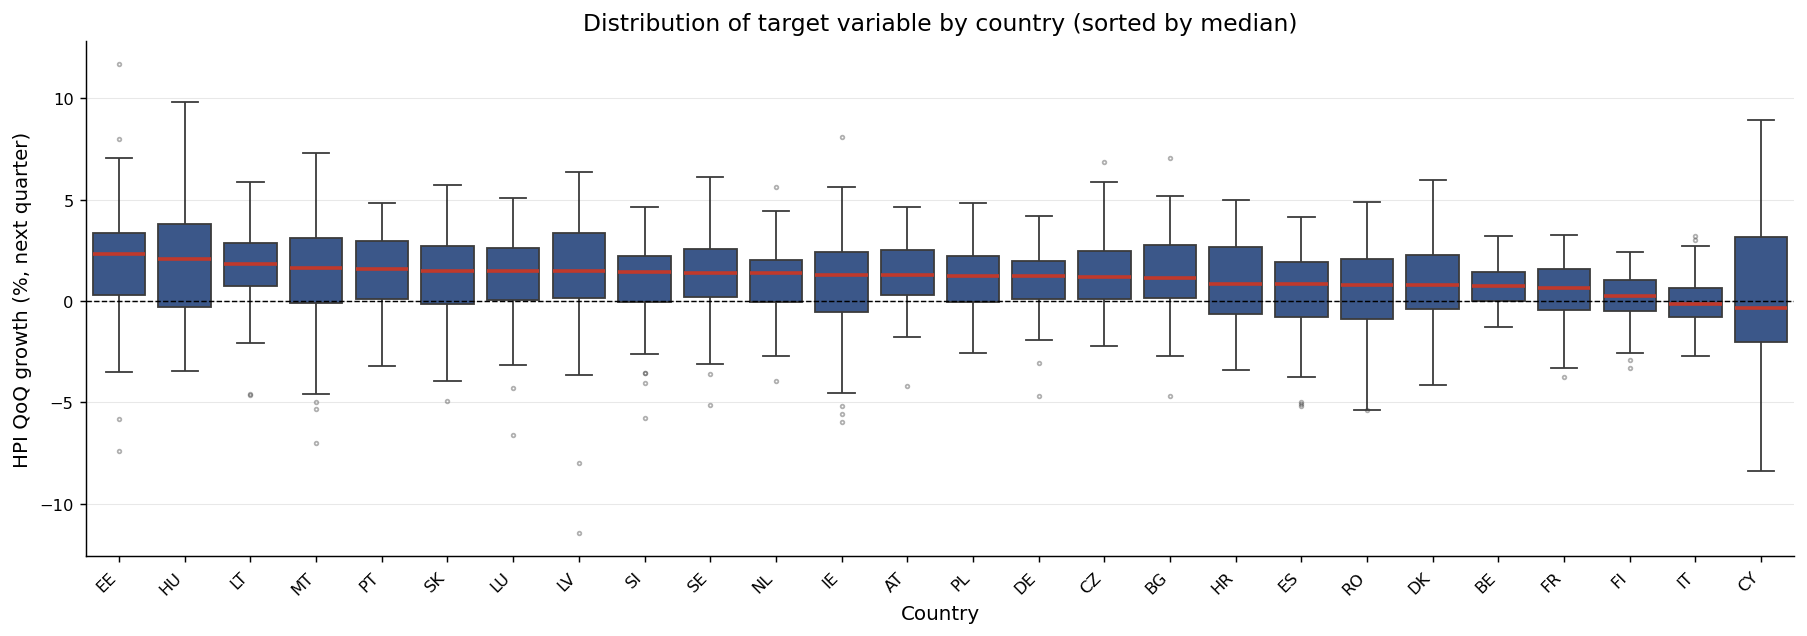

COUNTRY-LEVEL TARGET STATISTICS: 
              mean   std    min    max  count
country_code                                 
HU            2.15  2.99  -3.43   9.81     65
EE            2.03  2.95  -7.41  11.68     65
LT            1.63  2.07  -4.64   5.89     65
CZ            1.48  1.80  -2.23   6.87     65
PT            1.45  1.87  -3.19   4.82     65
LV            1.45  3.01 -11.44   6.36     65
AT            1.31  1.65  -4.19   4.63     60
BG            1.22  2.10  -4.70   7.08     65
LU            1.22  2.17  -6.62   5.08     65
PL            1.22  1.59  -2.58   4.83     60
SE            1.18  1.88  -5.13   6.09     80
SK            1.18  2.13  -4.94   5.74     65
MT            1.07  2.90  -7.01   7.31     65
HR            1.05  1.98  -3.38   5.01     65
NL            1.03  1.83  -3.92   5.63     65
DE            0.96  1.52  -4.69   4.22     65
SI            0.91  2.16  -5.75   4.66     65
DK            0.90  2.13  -4.16   5.97     65
IE            0.78  2.94  -5.94   8.09     65


In [7]:
# 2.3  Target by country (box plots)
country_order = (model_data.groupby("country_code")["target_hpi_next_q"]
                 .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=model_data,
    x="country_code", y="target_hpi_next_q",
    order=country_order,
    color=ACCENT,
    medianprops=dict(color=RED, linewidth=2),
    flierprops=dict(marker="o", markersize=2, alpha=0.4, color="#888888"),
    ax=ax
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Country")
ax.set_ylabel("HPI QoQ growth (%, next quarter)")
ax.set_title("Distribution of target variable by country (sorted by median)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("COUNTRY-LEVEL TARGET STATISTICS: ")
print(model_data.groupby("country_code")["target_hpi_next_q"]
      .agg(["mean","std","min","max","count"]).round(2)
      .sort_values("mean", ascending=False).to_string())

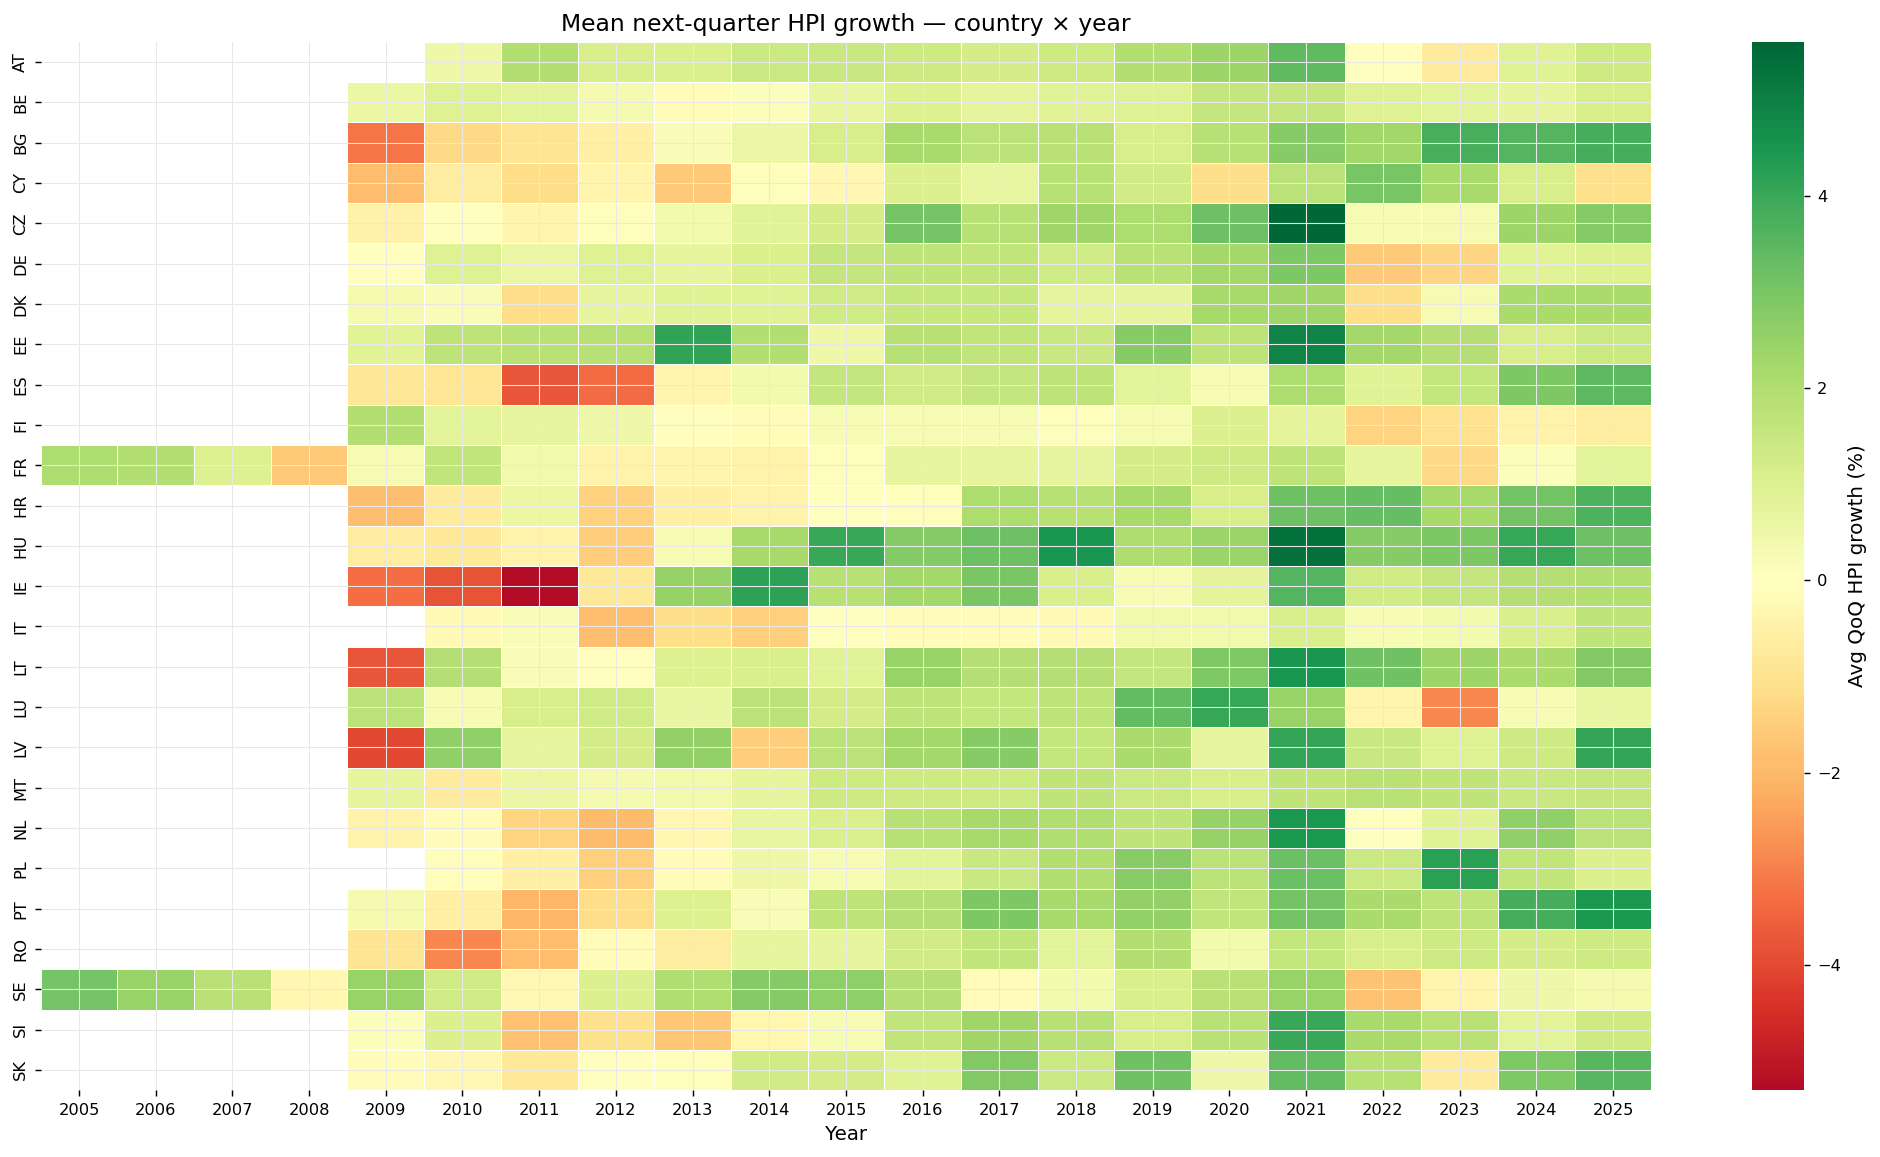

In [8]:
# 2.4  Heatmap: target by country and year
pivot = model_data.pivot_table(
    values="target_hpi_next_q", index="country_code", columns="year", aggfunc="mean")

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=0,
            linewidths=0.3, annot=False,
            cbar_kws={"label": "Avg QoQ HPI growth (%)"})
ax.set_title("Mean next-quarter HPI growth — country × year")
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


COUNTRY-WISE TARGET OUTLIER SUMMARY (IQR rule)
country_code  n_obs  n_outliers  median_target  min_target  max_target  outlier_share_pct
          EE     65           4           2.33       -7.41       11.68               6.15
          IE     65           4           1.31       -5.94        8.09               6.15
          SI     65           4           1.44       -5.75        4.66               6.15
          ES     65           3           0.82       -5.19        4.14               4.62
          MT     65           3           1.62       -7.01        7.31               4.62
          IT     60           2          -0.14       -2.73        3.23               3.33
          BG     65           2           1.14       -4.70        7.08               3.08
          DE     65           2           1.22       -4.69        4.22               3.08
          FI     65           2           0.27       -3.32        2.40               3.08
          LT     65           2           1.83       

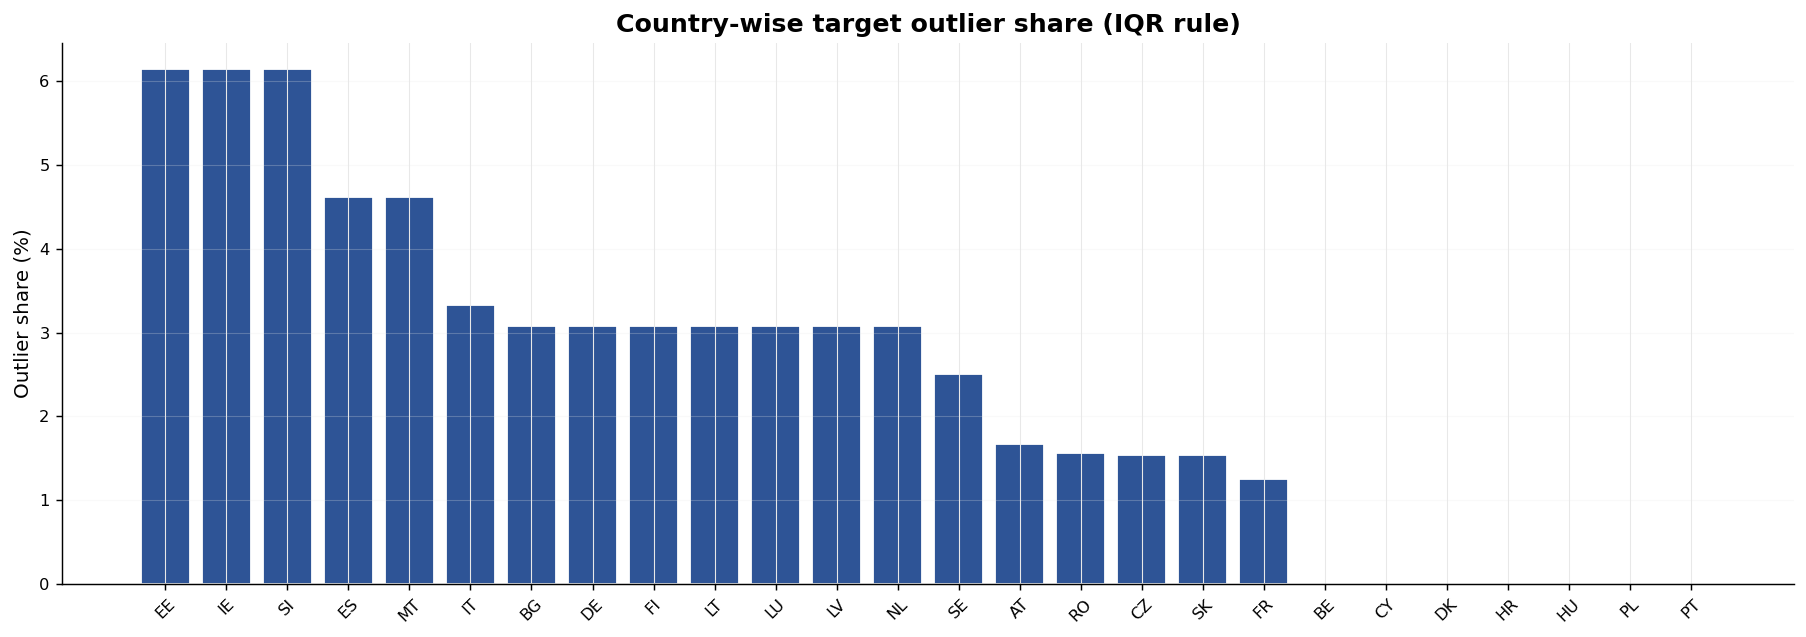

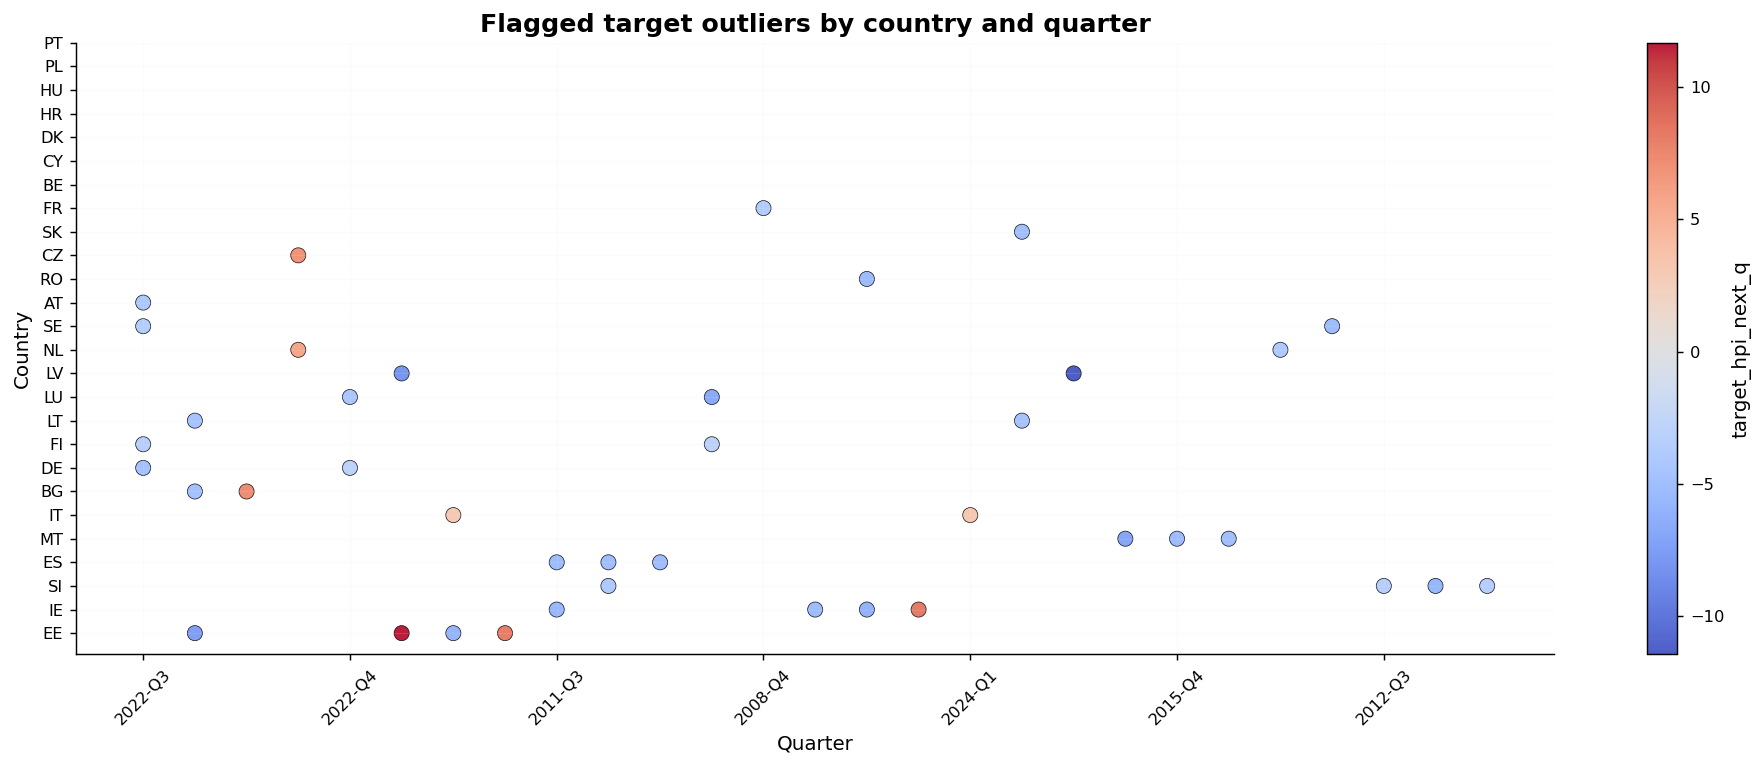

In [9]:
# 2.5 Country-wise outlier detection for the target
# To complement the pooled z-score screening, we detect outliers in the target variable relative to each country's own historical distribution. 
# This is more appropriate in a heterogeneous panel, where structurally high-growth markets and low-growth markets should not be judged against the same pooled cutoff.

# We use a country-wise IQR rule for `target_hpi_next_q`. Observations flagged as outliers are documented and visualised, 
# but not automatically removed, since extreme quarters may reflect economically meaningful crisis or boom dynamics rather than measurement error.

target_col = "target_hpi_next_q"

# Country-wise IQR bounds
country_iqr = (
    model_data.groupby("country_code")[target_col]
    .agg(
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        median="median"
    )
    .reset_index()
)

country_iqr["iqr"] = country_iqr["q3"] - country_iqr["q1"]
country_iqr["lower_bound"] = country_iqr["q1"] - 1.5 * country_iqr["iqr"]
country_iqr["upper_bound"] = country_iqr["q3"] + 1.5 * country_iqr["iqr"]

target_outliers = model_data.merge(
    country_iqr[["country_code", "median", "lower_bound", "upper_bound"]],
    on="country_code",
    how="left"
).copy()

target_outliers["target_outlier_country_iqr"] = (
    (target_outliers[target_col] < target_outliers["lower_bound"]) |
    (target_outliers[target_col] > target_outliers["upper_bound"])
)

# Optional companion metric: country-wise z-score
country_stats = (
    model_data.groupby("country_code")[target_col]
    .agg(country_mean="mean", country_std="std")
    .reset_index()
)
target_outliers = target_outliers.merge(country_stats, on="country_code", how="left")
target_outliers["target_country_z"] = (
    (target_outliers[target_col] - target_outliers["country_mean"]) /
    target_outliers["country_std"]
)

# Summary by country
outlier_summary = (
    target_outliers.groupby("country_code")
    .agg(
        n_obs=(target_col, "count"),
        n_outliers=("target_outlier_country_iqr", "sum"),
        median_target=(target_col, "median"),
        min_target=(target_col, "min"),
        max_target=(target_col, "max")
    )
    .reset_index()
)

outlier_summary["outlier_share_pct"] = (
    100 * outlier_summary["n_outliers"] / outlier_summary["n_obs"]
)

outlier_summary = outlier_summary.sort_values(
    ["outlier_share_pct", "n_outliers", "country_code"],
    ascending=[False, False, True]
)

print("COUNTRY-WISE TARGET OUTLIER SUMMARY (IQR rule)")
print(outlier_summary.round(2).to_string(index=False))

# Extract flagged rows
flagged_target_outliers = target_outliers[
    target_outliers["target_outlier_country_iqr"]
].copy()

print("\nFLAGGED TARGET OUTLIERS")
print(
    flagged_target_outliers[
        ["country_code", "quarter", target_col, "median", "lower_bound", "upper_bound", "target_country_z"]
    ]
    .sort_values(["country_code", "quarter"])
    .round(2)
    .to_string(index=False)
)

# Plot 1: outlier share by country
fig, ax = plt.subplots(figsize=(14, 5))
plot_df = outlier_summary.sort_values("outlier_share_pct", ascending=False)

ax.bar(plot_df["country_code"], plot_df["outlier_share_pct"], color=ACCENT, edgecolor="white")
ax.set_title("Country-wise target outlier share (IQR rule)", fontsize=14, weight="bold")
ax.set_ylabel("Outlier share (%)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: timeline of flagged outliers
if len(flagged_target_outliers) > 0:
    flagged_target_outliers = flagged_target_outliers.sort_values(["country_code", "quarter"])
    country_order = outlier_summary["country_code"].tolist()
    y_map = {c: i for i, c in enumerate(country_order)}
    flagged_target_outliers["y_pos"] = flagged_target_outliers["country_code"].map(y_map)

    fig, ax = plt.subplots(figsize=(15, 6))
    sc = ax.scatter(
        flagged_target_outliers["quarter"],
        flagged_target_outliers["y_pos"],
        s=70,
        c=flagged_target_outliers[target_col],
        cmap="coolwarm",
        alpha=0.9,
        edgecolor="black",
        linewidth=0.4
    )

    ax.set_yticks(range(len(country_order)))
    ax.set_yticklabels(country_order)
    ax.set_title("Flagged target outliers by country and quarter", fontsize=14, weight="bold")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Country")
    ax.grid(alpha=0.15)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("target_hpi_next_q")

    # reduce x tick crowding
    xticks = flagged_target_outliers["quarter"].drop_duplicates().tolist()
    ax.set_xticks(xticks[::4] if len(xticks) > 12 else xticks)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Country-wise outlier detection using the IQR rule shows that extreme target values are concentrated in a limited number of countries rather than being broadly distributed across the panel. The highest outlier shares are observed in Estonia, Ireland, and Slovenia, followed by Spain and Malta, while many countries show few or no outliers. The flagged quarters cluster mainly around the Global Financial Crisis and the post-2022 tightening period, suggesting that these observations reflect economically meaningful boom-bust and regime-shift dynamics rather than random noise or clear data errors.

## 3. Feature Distributions

Distributions of all numeric predictor variables. We are looking for: extreme outliers, heavy tails, variables that may need transformation, and variables that show little variation (low information content).


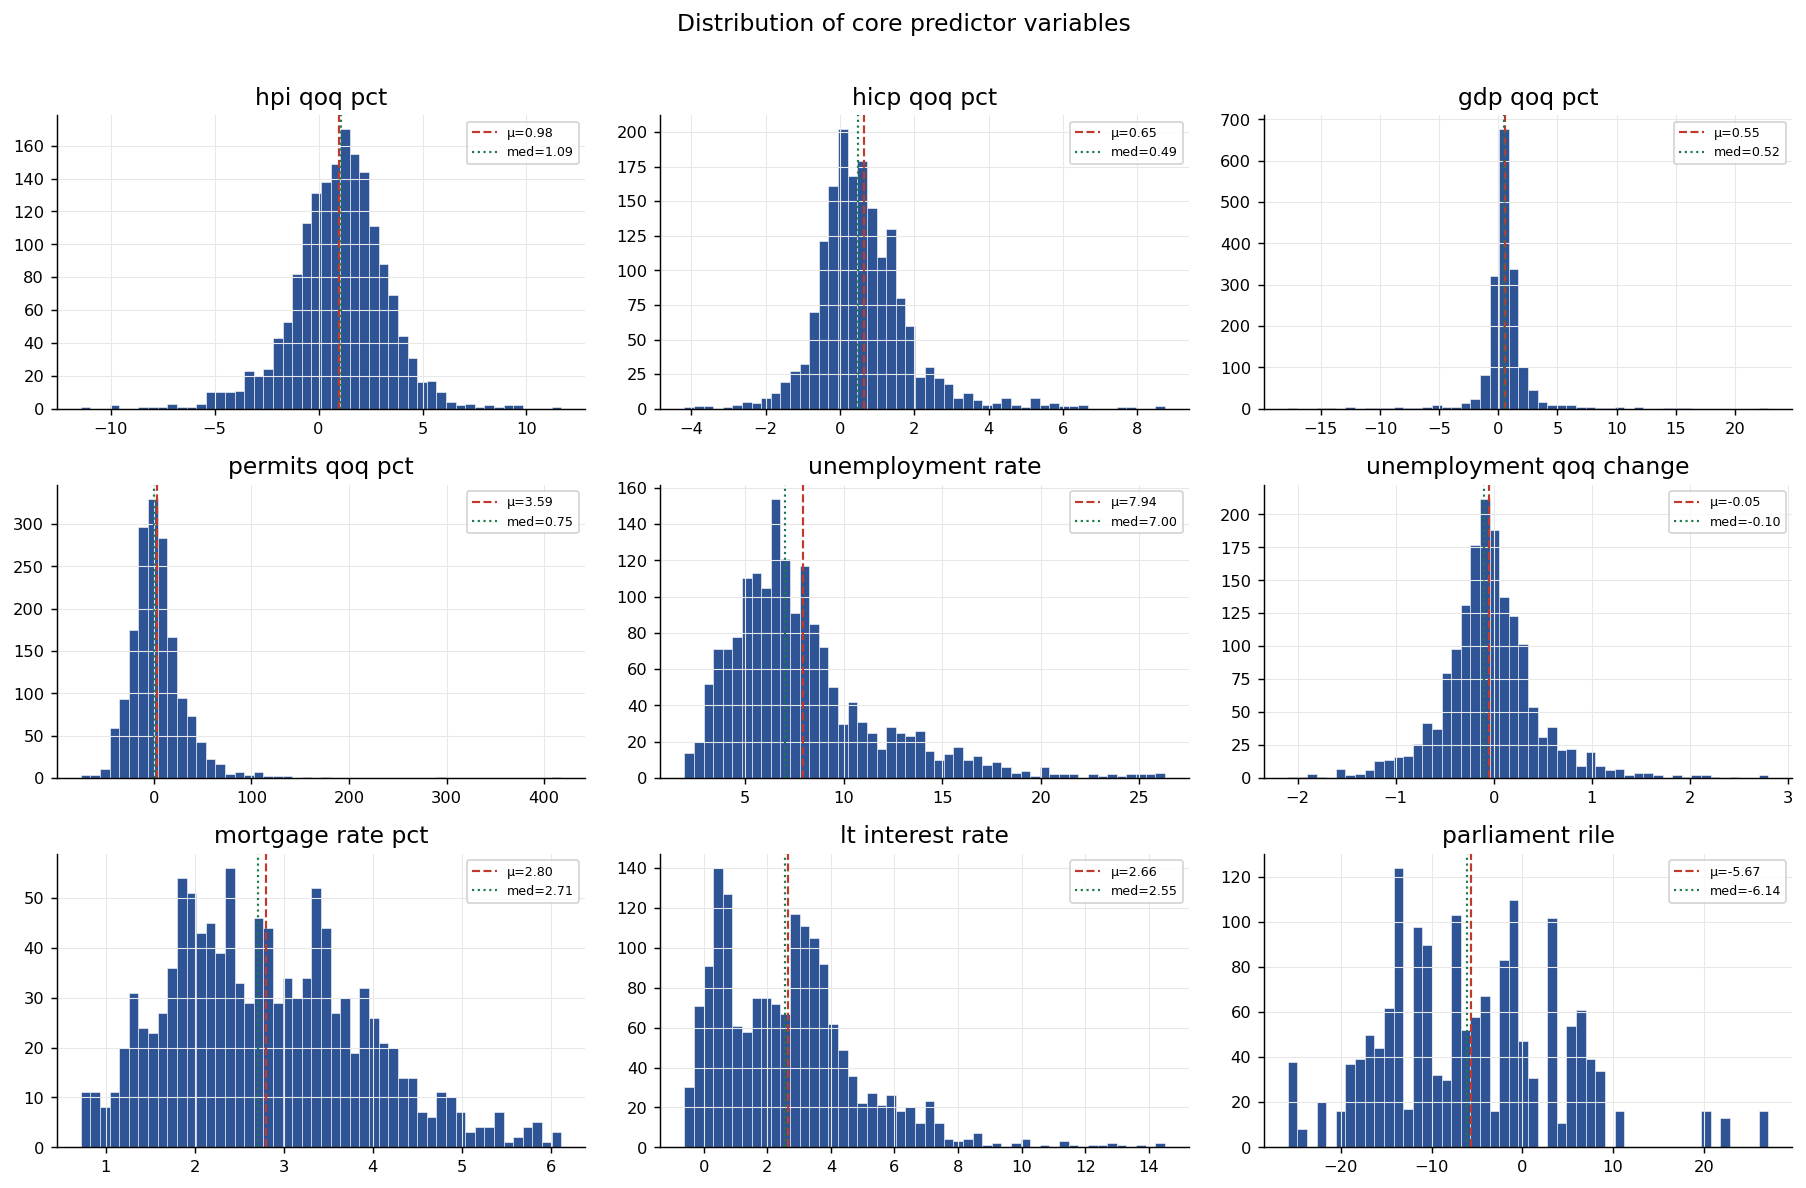

In [10]:
# 3.1  Histograms for all core predictors
core_features = [
    "hpi_qoq_pct", "hicp_qoq_pct", "gdp_qoq_pct", "permits_qoq_pct",
    "unemployment_rate", "unemployment_qoq_change",
    "mortgage_rate_pct", "lt_interest_rate", "parliament_rile"
]
core_features = [c for c in core_features if c in model_data.columns]

n = len(core_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(core_features):
    data = model_data[col].dropna()
    axes[i].hist(data, bins=50, color=ACCENT, edgecolor="white", linewidth=0.3)
    axes[i].axvline(data.mean(), color=RED, linestyle="--", linewidth=1.2,
                    label=f"μ={data.mean():.2f}")
    axes[i].axvline(data.median(), color=GREEN, linestyle=":", linewidth=1.2,
                    label=f"med={data.median():.2f}")
    axes[i].set_title(col.replace("_", " "))
    axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of core predictor variables", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [11]:
# 3.2  Outlier summary (z-score > 3)
from scipy.stats import zscore

numeric_cols = model_data.select_dtypes(include=np.number).columns
numeric_cols = [c for c in numeric_cols if c not in
                ["year","quarter_num","eurozone_member_current","eurozone_member_timevarying"]]

z_scores = model_data[numeric_cols].apply(zscore, nan_policy="omit")
outlier_counts = (z_scores.abs() > 3).sum().sort_values(ascending=False)
outlier_counts = outlier_counts[outlier_counts > 0]

print("OUTLIER COUNTS (|z-score| > 3):")
print(outlier_counts.to_string())

# Show the actual outlier rows for the target variable
target_z = z_scores["target_hpi_next_q"].abs()
extreme = model_data[target_z > 3][["country_code","quarter","target_hpi_next_q"]].copy()
extreme["z_score"] = target_z[target_z > 3].values
print(f"\nEXTREME TARGET OBSERVATIONS (|z|>3): {len(extreme)} rows")
print(extreme.sort_values("z_score", ascending=False).to_string())


OUTLIER COUNTS (|z-score| > 3):
population_density         50
gdp_qoq_pct                43
gdp_qoq_pct_lag2           43
gdp_qoq_pct_lag1           43
hicp_q                     40
gdp_index                  37
hicp_qoq_pct_lag2          36
hicp_qoq_pct               35
hicp_qoq_pct_lag1          35
unemployment_qoq_change    34
unemployment_rate_lag1     28
unemployment_rate_lag2     28
unemployment_rate          28
hpi                        25
lt_interest_rate_lag2      23
building_permits_index     23
lt_interest_rate_lag1      23
permits_qoq_pct_lag2       22
hpi_qoq_pct_lag2           22
permits_qoq_pct_lag1       22
permits_qoq_pct            22
hpi_qoq_pct_lag1           21
hpi_qoq_pct                20
lt_interest_rate           19
target_hpi_next_q          18
parliament_rile_lag1       16
parliament_rile            16
parliament_rile_lag2       16
mortgage_rate_pct_lag2      4
mortgage_rate_pct_lag1      4
mortgage_rate_pct           3

EXTREME TARGET OBSERVATIONS (|z|>3): 

PREDICTOR-LEVEL OUTLIER SUMMARY
                   total_outliers  mean_outlier_share_pct  max_country_share_pct
variable                                                                        
gdp_qoq_pct                   142                    8.40                  15.00
hicp_qoq_pct                   58                    3.42                   9.23
permits_qoq_pct                48                    2.82                   9.23
mortgage_rate_pct              29                    2.65                  19.57
lt_interest_rate               20                    1.18                  10.77

TOP COUNTRY-PREDICTOR COMBINATIONS BY OUTLIER SHARE
country_code  n_obs  n_outliers  median_value  min_value  max_value  outlier_share_pct          variable
          LV     46           9          2.84       2.40       5.90              19.57 mortgage_rate_pct
          LU     65          10          2.04       1.28       4.42              15.38 mortgage_rate_pct
          IT     60           9  

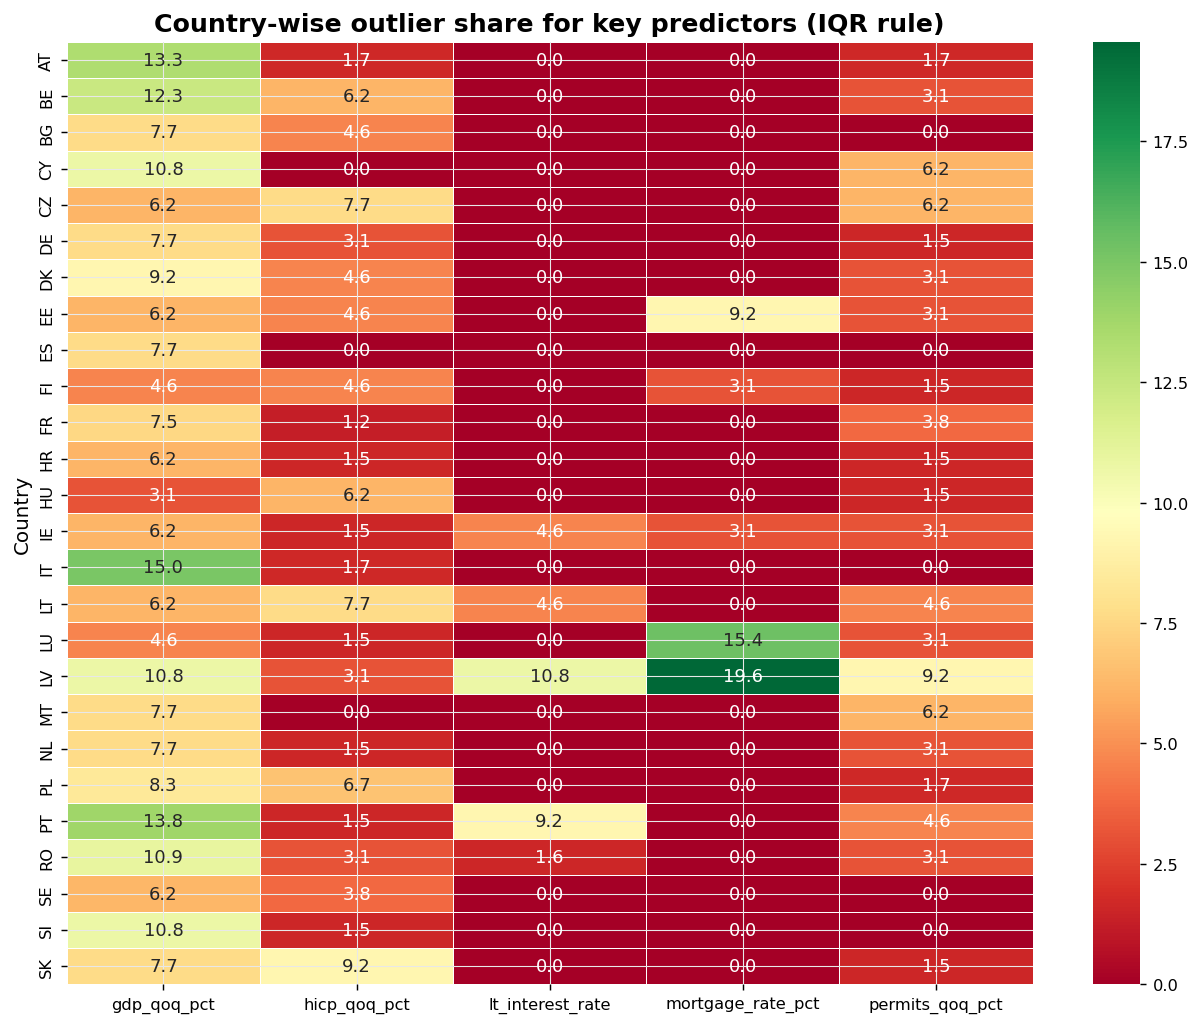

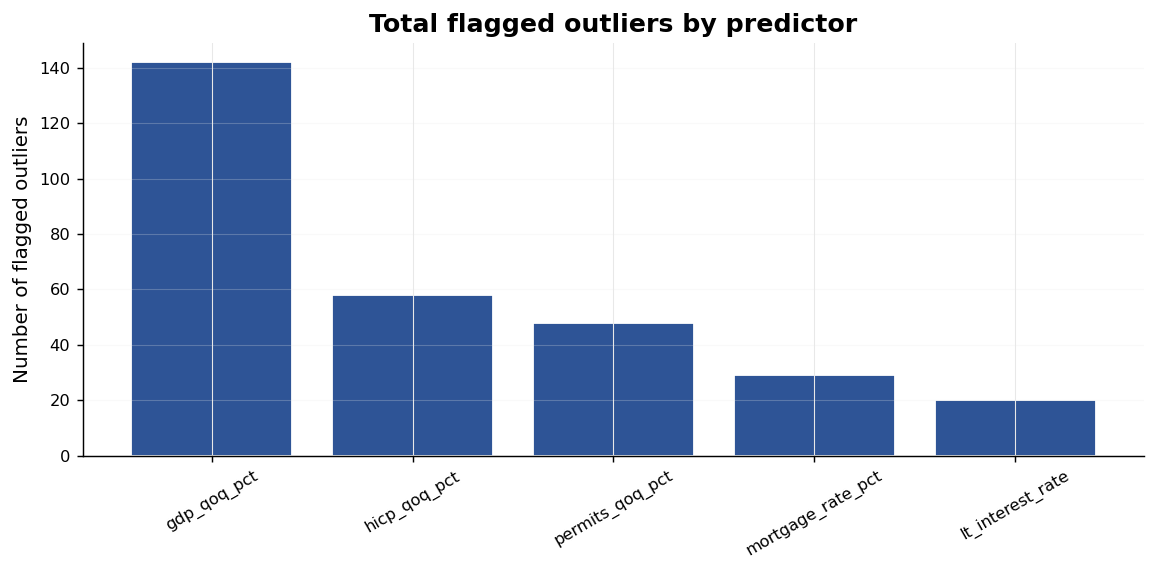

In [12]:
# 3.3 Country-wise outlier detection for key predictors
# To extend the pooled z-score screening, we also examine outliers in the main predictors relative to each country's own historical distribution. 
# This is useful in a heterogeneous macro-financial panel, where the same absolute value may be normal for one country but extreme for another.

# We apply a country-wise IQR rule to the main predictors: GDP growth, inflation, building permits growth, long-term interest rates, and mortgage rates. 
# The results are used descriptively to identify unusually extreme predictor realizations, not to automatically remove observations.

import seaborn as sns

predictor_cols = [
    "gdp_qoq_pct",
    "hicp_qoq_pct",
    "permits_qoq_pct",
    "lt_interest_rate",
    "mortgage_rate_pct"
]

all_predictor_summaries = []
all_flagged_predictors = []

for var in predictor_cols:
    df_var = model_data[["country_code", "quarter", var]].dropna().copy()

    # country-wise IQR bounds
    bounds = (
        df_var.groupby("country_code")[var]
        .agg(
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            median="median",
            n_obs="count"
        )
        .reset_index()
    )

    bounds["iqr"] = bounds["q3"] - bounds["q1"]
    bounds["lower_bound"] = bounds["q1"] - 1.5 * bounds["iqr"]
    bounds["upper_bound"] = bounds["q3"] + 1.5 * bounds["iqr"]

    df_var = df_var.merge(
        bounds[["country_code", "median", "lower_bound", "upper_bound", "n_obs"]],
        on="country_code",
        how="left"
    )

    df_var["is_outlier"] = (
        (df_var[var] < df_var["lower_bound"]) |
        (df_var[var] > df_var["upper_bound"])
    )
    df_var["variable"] = var

    flagged = df_var[df_var["is_outlier"]].copy()
    all_flagged_predictors.append(flagged)

    summary = (
        df_var.groupby("country_code")
        .agg(
            n_obs=(var, "count"),
            n_outliers=("is_outlier", "sum"),
            median_value=(var, "median"),
            min_value=(var, "min"),
            max_value=(var, "max")
        )
        .reset_index()
    )
    summary["outlier_share_pct"] = 100 * summary["n_outliers"] / summary["n_obs"]
    summary["variable"] = var

    all_predictor_summaries.append(summary)

predictor_outlier_summary = pd.concat(all_predictor_summaries, ignore_index=True)
flagged_predictor_outliers = pd.concat(all_flagged_predictors, ignore_index=True)

# Compact summary by predictor
predictor_level_summary = (
    predictor_outlier_summary.groupby("variable")
    .agg(
        total_outliers=("n_outliers", "sum"),
        mean_outlier_share_pct=("outlier_share_pct", "mean"),
        max_country_share_pct=("outlier_share_pct", "max")
    )
    .sort_values("total_outliers", ascending=False)
)

print("PREDICTOR-LEVEL OUTLIER SUMMARY")
print(predictor_level_summary.round(2).to_string())

print("\nTOP COUNTRY-PREDICTOR COMBINATIONS BY OUTLIER SHARE")
top_predictor_outliers = predictor_outlier_summary.sort_values(
    ["outlier_share_pct", "n_outliers", "country_code"],
    ascending=[False, False, True]
)
print(top_predictor_outliers.head(20).round(2).to_string(index=False))

# Heatmap: outlier share by country and predictor
heatmap_df = predictor_outlier_summary.pivot(
    index="country_code",
    columns="variable",
    values="outlier_share_pct"
).fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=0.5)
plt.title("Country-wise outlier share for key predictors (IQR rule)", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Bar chart: total number of flagged outliers by predictor
plot_df = predictor_level_summary.reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(plot_df["variable"], plot_df["total_outliers"], color=ACCENT, edgecolor="white")
ax.set_title("Total flagged outliers by predictor", fontsize=14, weight="bold")
ax.set_ylabel("Number of flagged outliers")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Temporal Trends

How key variables evolve over time. We want to confirm that our data captures the major economic episodes and check for any anomalous patterns that might indicate data quality issues.


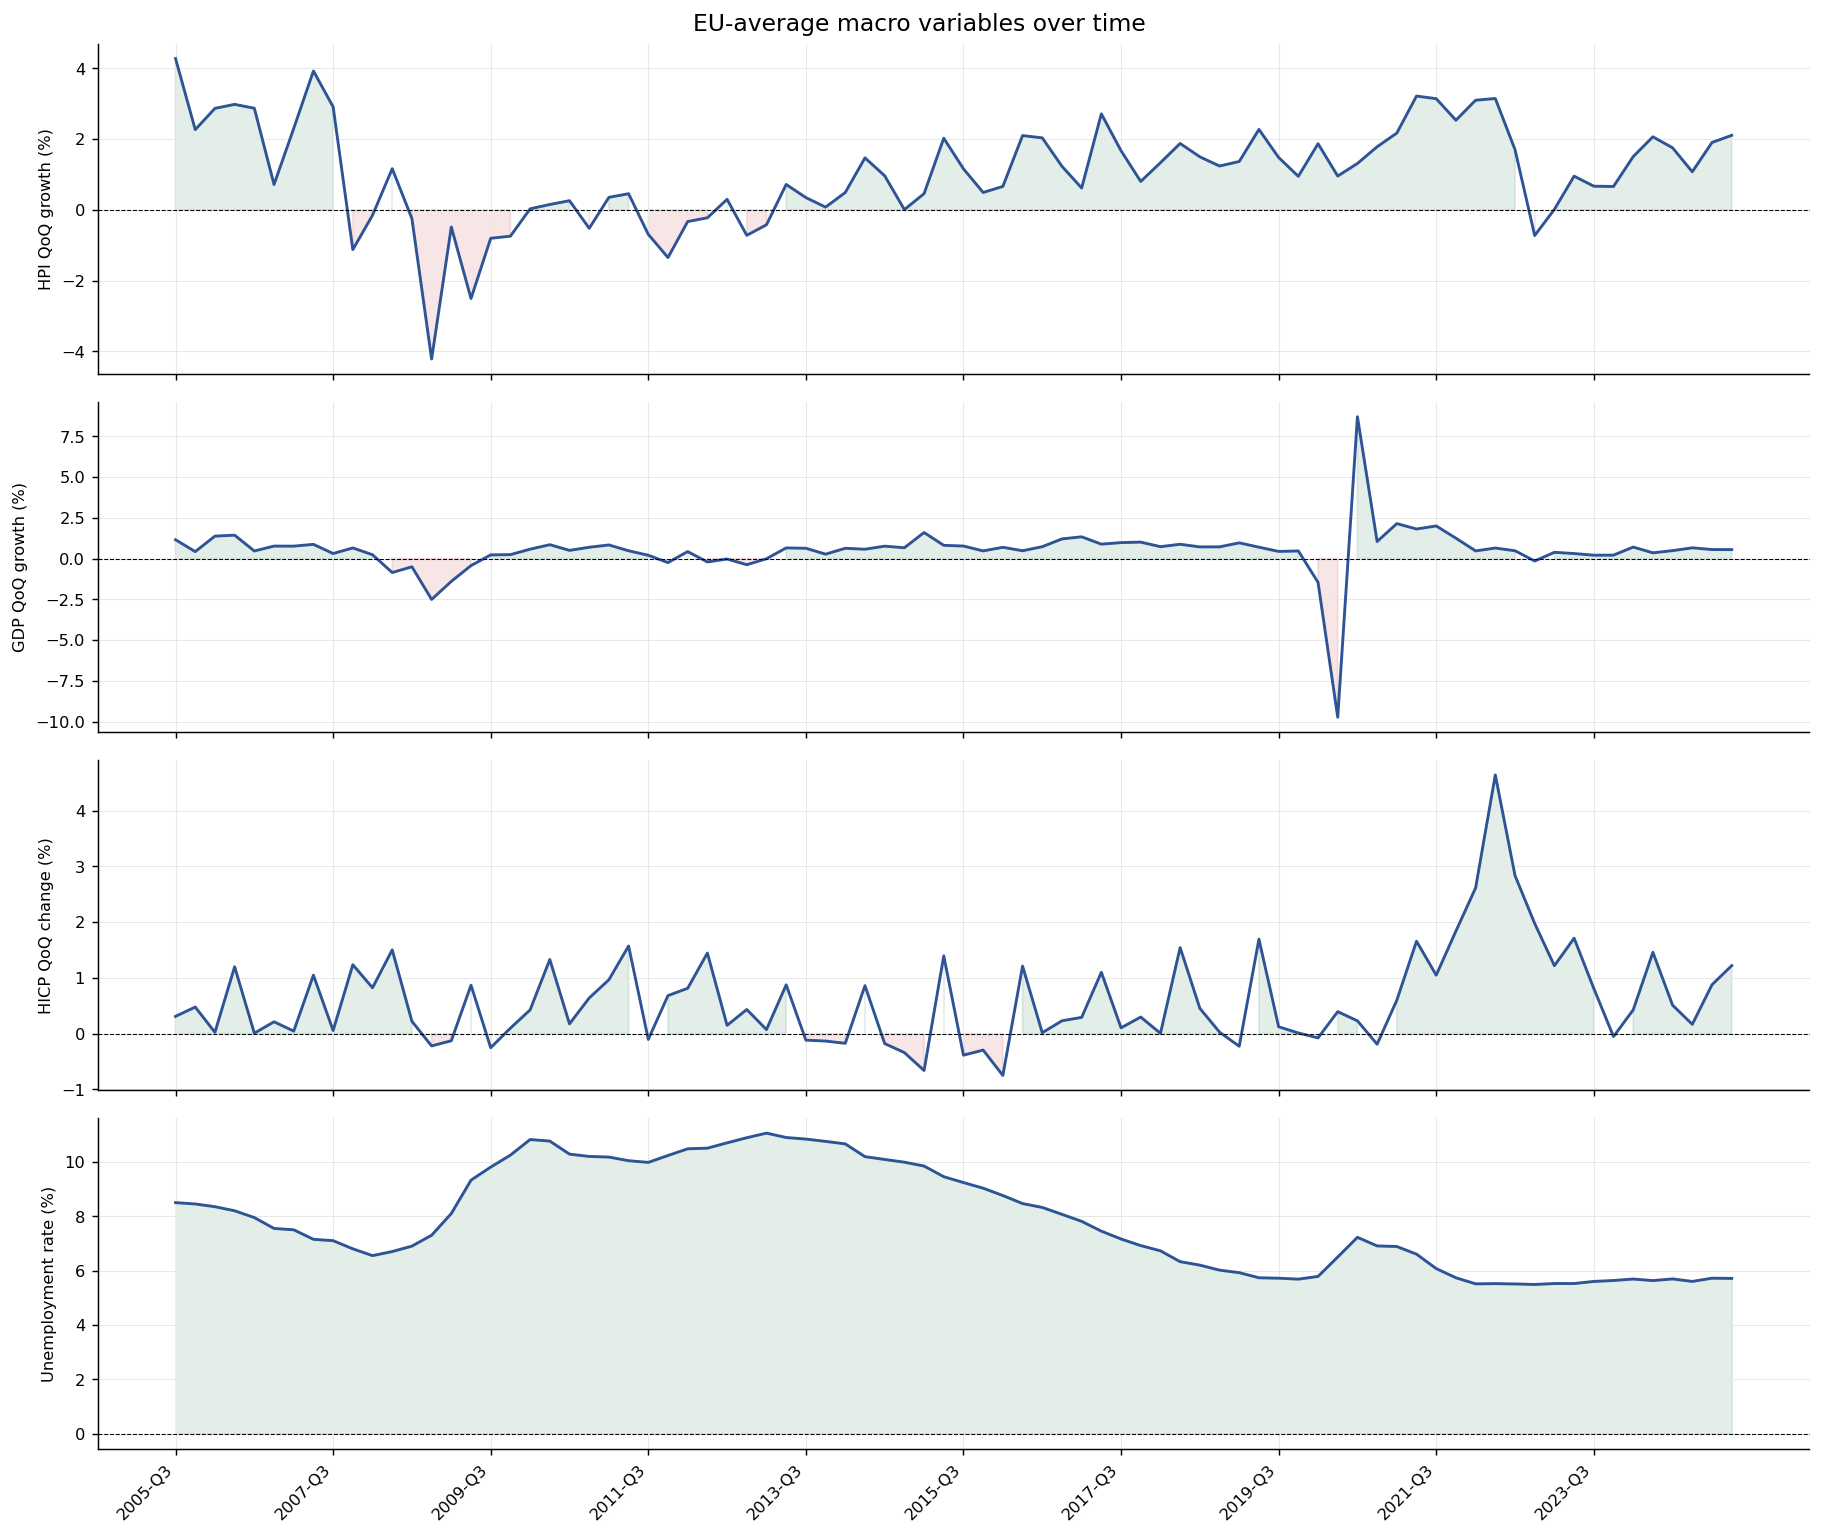

In [13]:
# 4.1  Key macro variables over time (EU average)
trend_vars = {
    "hpi_qoq_pct":         "HPI QoQ growth (%)",
    "gdp_qoq_pct":         "GDP QoQ growth (%)",
    "hicp_qoq_pct":        "HICP QoQ change (%)",
    "unemployment_rate":   "Unemployment rate (%)",
}
trend_vars = {k: v for k, v in trend_vars.items() if k in model_data.columns}

fig, axes = plt.subplots(len(trend_vars), 1, figsize=(14, 3 * len(trend_vars)), sharex=True)
if len(trend_vars) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, trend_vars.items()):
    eu_ts = model_data.groupby("quarter")[col].mean()
    ax.plot(eu_ts.index, eu_ts.values, color=ACCENT, linewidth=1.6)
    ax.fill_between(eu_ts.index, eu_ts.values, 0,
                    where=(eu_ts.values >= 0), alpha=0.12, color=GREEN)
    ax.fill_between(eu_ts.index, eu_ts.values, 0,
                    where=(eu_ts.values < 0), alpha=0.12, color=RED)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_ylabel(label, fontsize=9)

    ticks = eu_ts.index[::8]
    ax.set_xticks(ticks)

axes[-1].set_xticklabels(ticks, rotation=45, ha="right")
plt.suptitle("EU-average macro variables over time", fontsize=13)
plt.tight_layout()
plt.show()


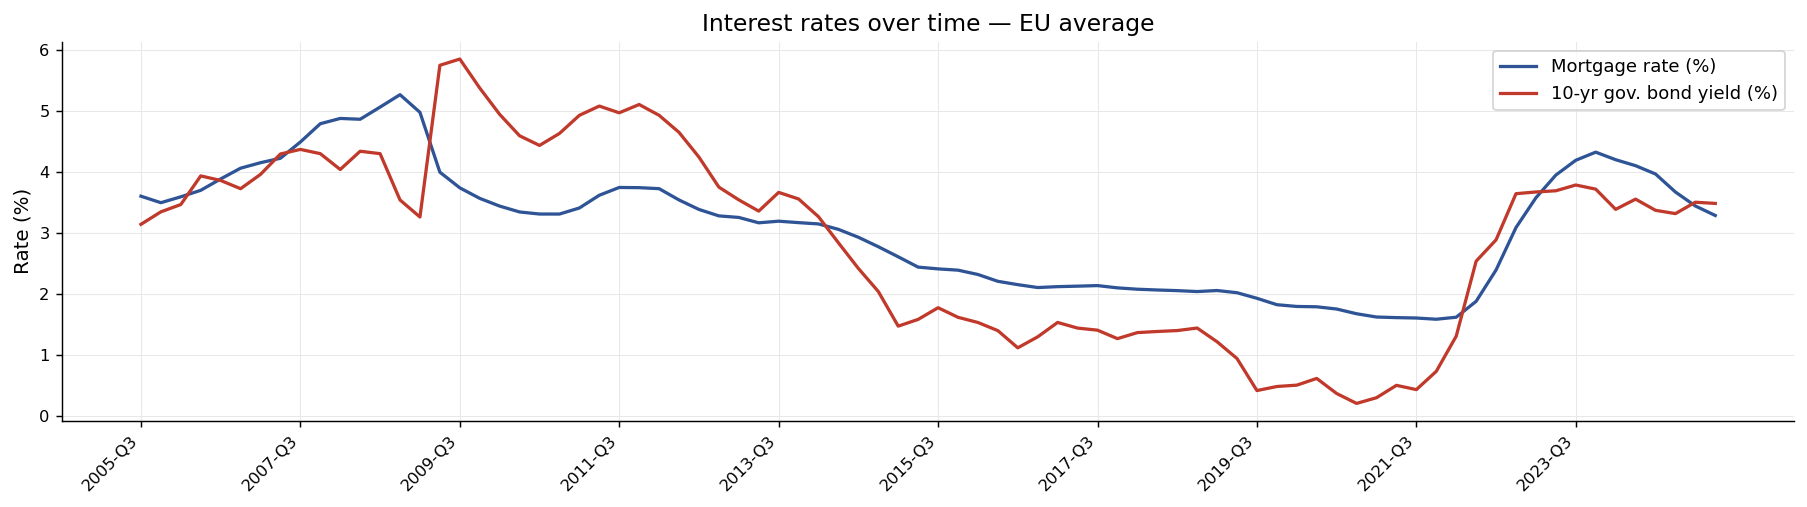

In [14]:
# 4.2  Interest rates over time (EU average)
rate_vars = {k: v for k, v in {
    "mortgage_rate_pct": "Mortgage rate (%)",
    "lt_interest_rate":  "10-yr gov. bond yield (%)"
}.items() if k in model_data.columns}

if rate_vars:
    fig, ax = plt.subplots(figsize=(14, 4))
    colors = [ACCENT, RED]
    for (col, label), color in zip(rate_vars.items(), colors):
        ts = model_data.groupby("quarter")[col].mean()
        ax.plot(ts.index, ts.values, color=color, linewidth=1.8, label=label)

    ticks = ts.index[::8]
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks, rotation=45, ha="right")
    ax.set_ylabel("Rate (%)")
    ax.set_title("Interest rates over time — EU average")
    ax.legend()
    plt.tight_layout()
    plt.show()


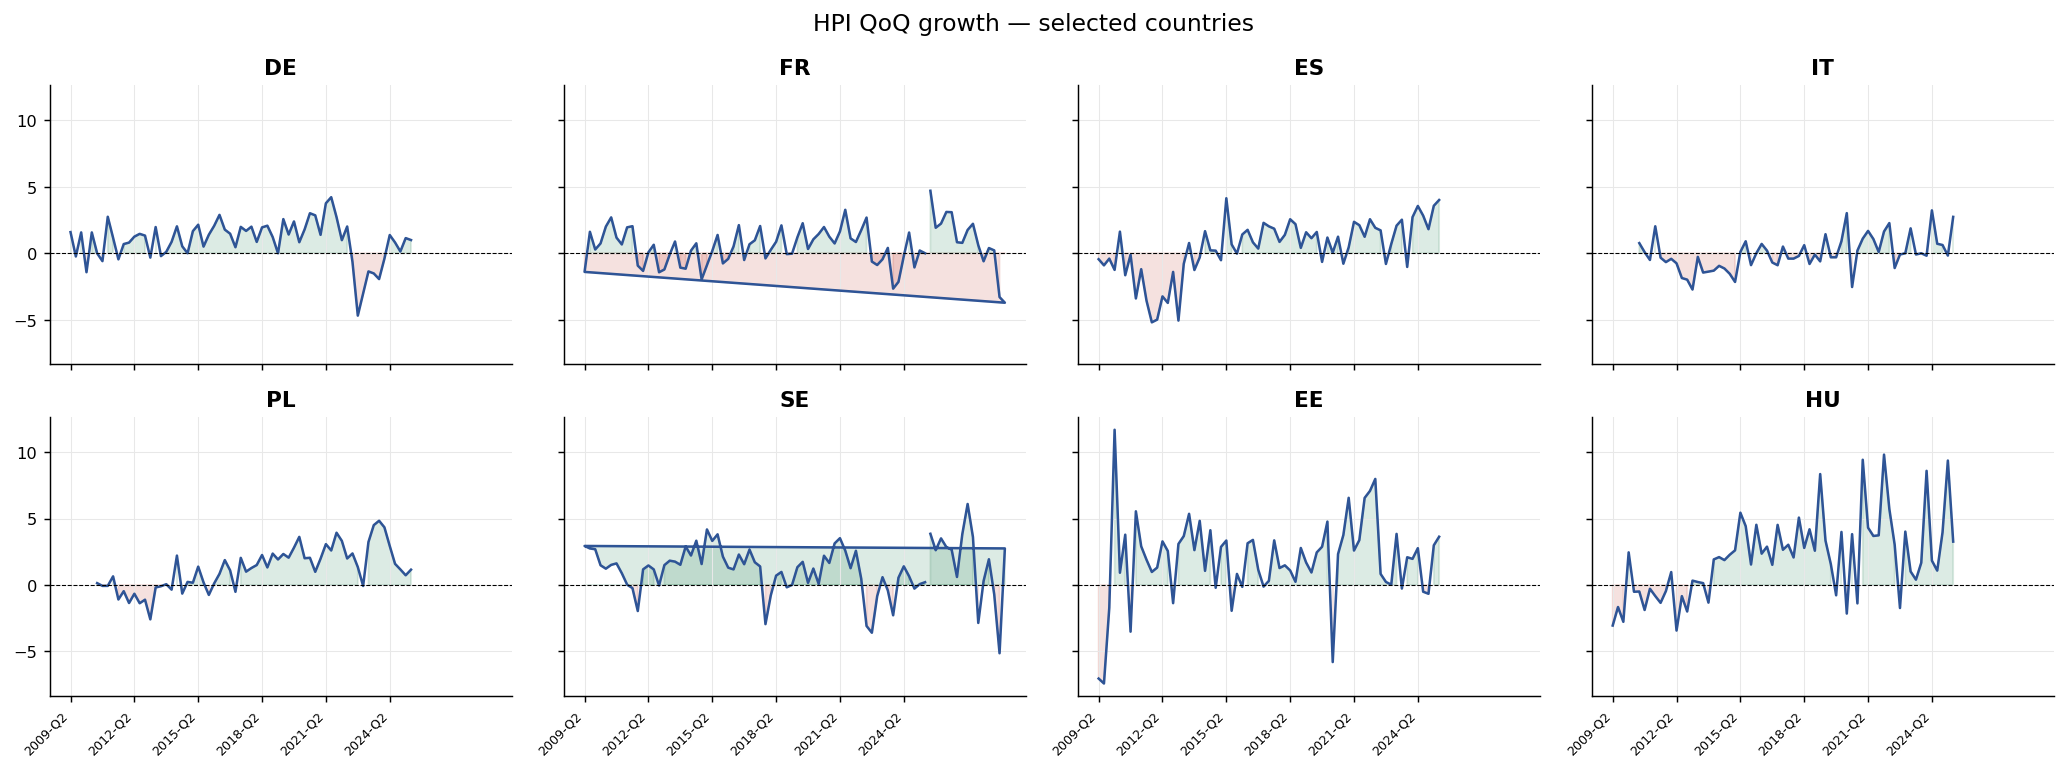

In [15]:
# 4.3  HPI growth for selected countries
# A representative sample: large western, southern, eastern, nordic
sample_countries = [c for c in ["DE","FR","ES","IT","PL","SE","EE","HU","IE","NL"]
                    if c in model_data["country_code"].unique()][:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, cc in enumerate(sample_countries):
    sub = model_data[model_data["country_code"] == cc].sort_values("quarter")
    axes[i].plot(sub["quarter"], sub["hpi_qoq_pct"], color=ACCENT, linewidth=1.4)
    axes[i].axhline(0, color="black", linewidth=0.6, linestyle="--")
    axes[i].fill_between(sub["quarter"], sub["hpi_qoq_pct"], 0,
                         where=(sub["hpi_qoq_pct"] >= 0), alpha=0.15, color=GREEN)
    axes[i].fill_between(sub["quarter"], sub["hpi_qoq_pct"], 0,
                         where=(sub["hpi_qoq_pct"] < 0), alpha=0.15, color=RED)
    axes[i].set_title(cc, fontsize=12, fontweight="bold")
    ticks = sub["quarter"].iloc[::12]
    axes[i].set_xticks(ticks)
    axes[i].set_xticklabels(ticks, rotation=45, ha="right", fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("HPI QoQ growth — selected countries", fontsize=13)
plt.tight_layout()
plt.show()


## 5. Correlation Analysis

Two views: features vs each other (to detect multicollinearity) and features vs the target (to identify predictive signal). This directly informs feature selection for the models.


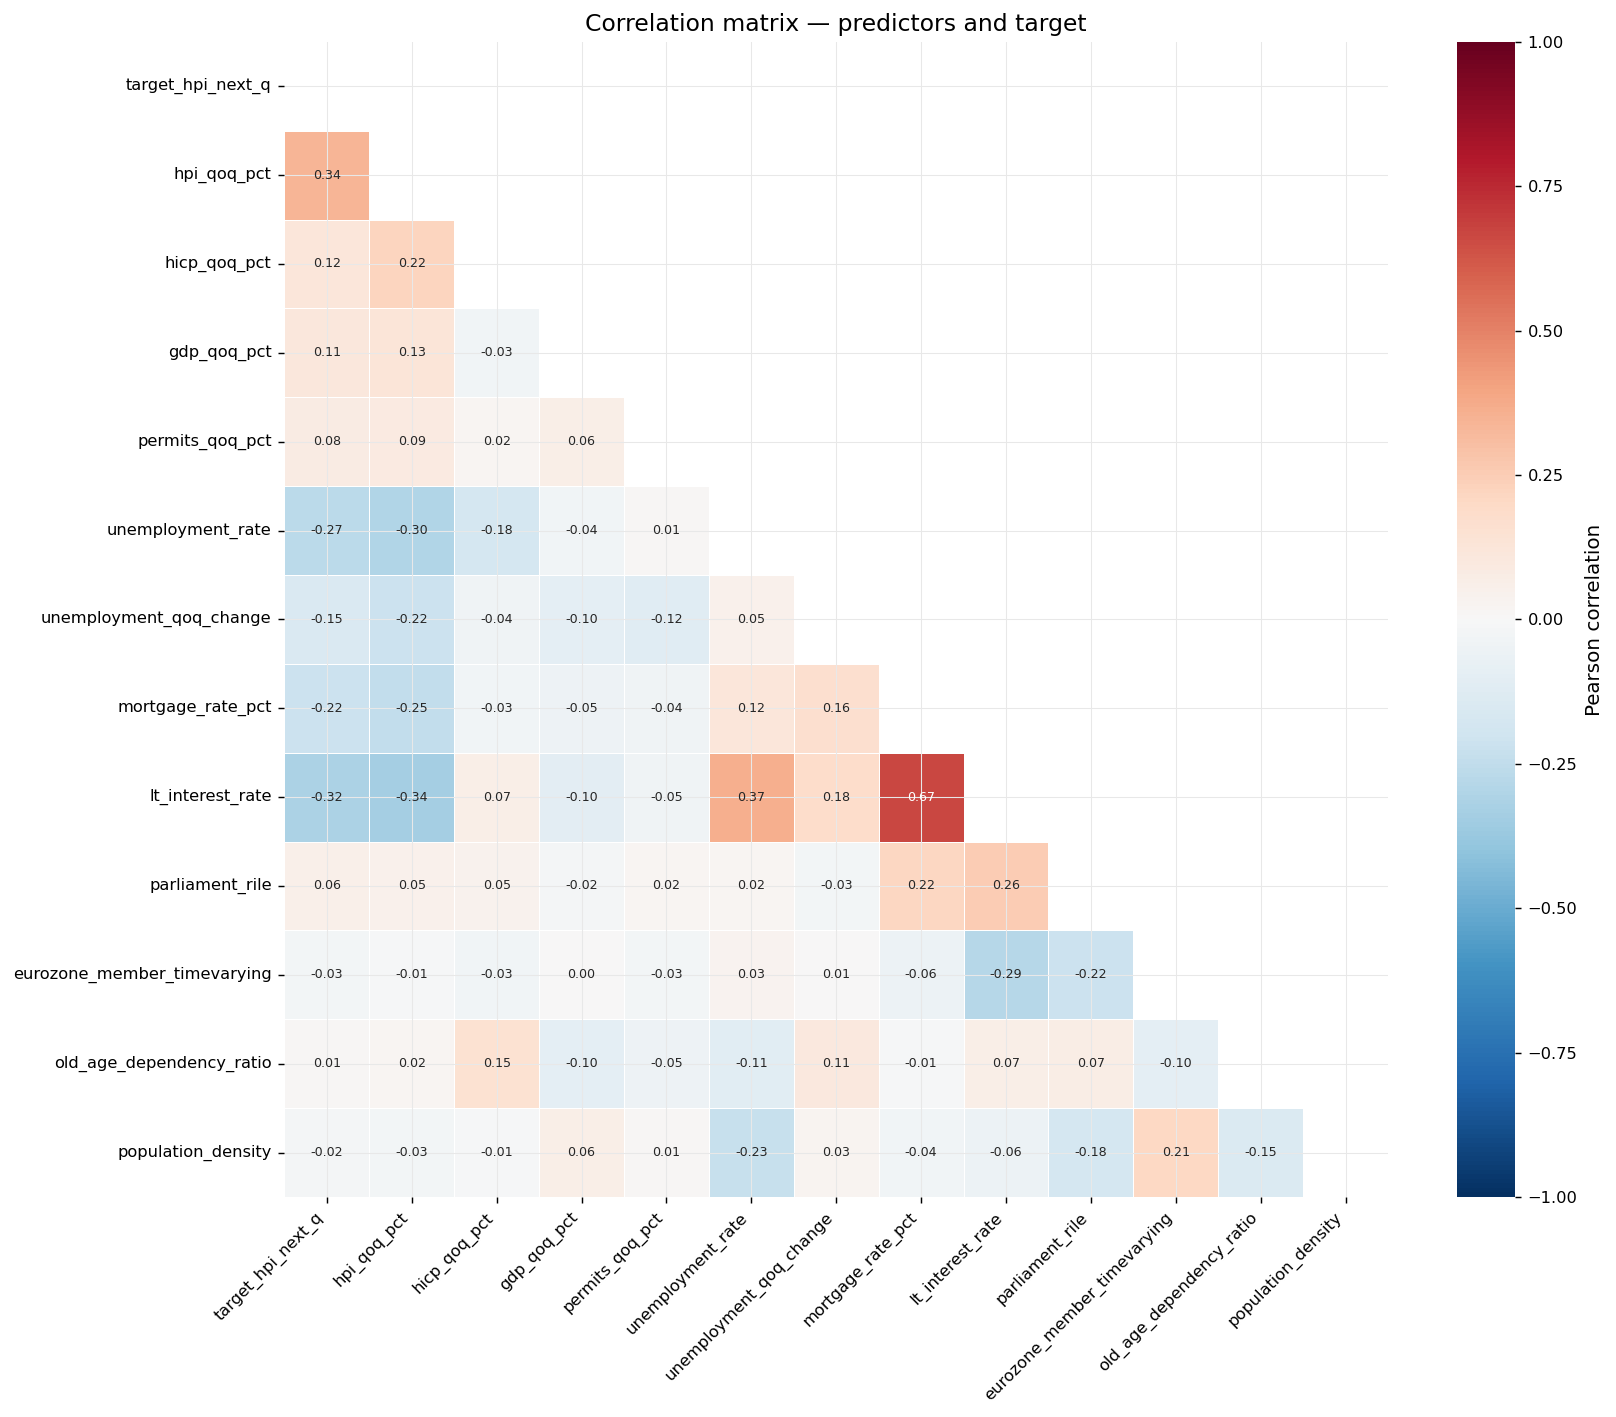

In [16]:
# 5.1  Full correlation heatmap
# Use current-period features (not lags) to avoid visual clutter
feat_cols = [
    "target_hpi_next_q",
    "hpi_qoq_pct", "hicp_qoq_pct", "gdp_qoq_pct", "permits_qoq_pct",
    "unemployment_rate", "unemployment_qoq_change",
    "mortgage_rate_pct", "lt_interest_rate",
    "parliament_rile", "eurozone_member_timevarying",
    "old_age_dependency_ratio", "population_density"
]
feat_cols = [c for c in feat_cols if c in model_data.columns]

corr = model_data[feat_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, mask=mask, ax=ax, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.3, cbar_kws={"label": "Pearson correlation"})
ax.set_title("Correlation matrix — predictors and target", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


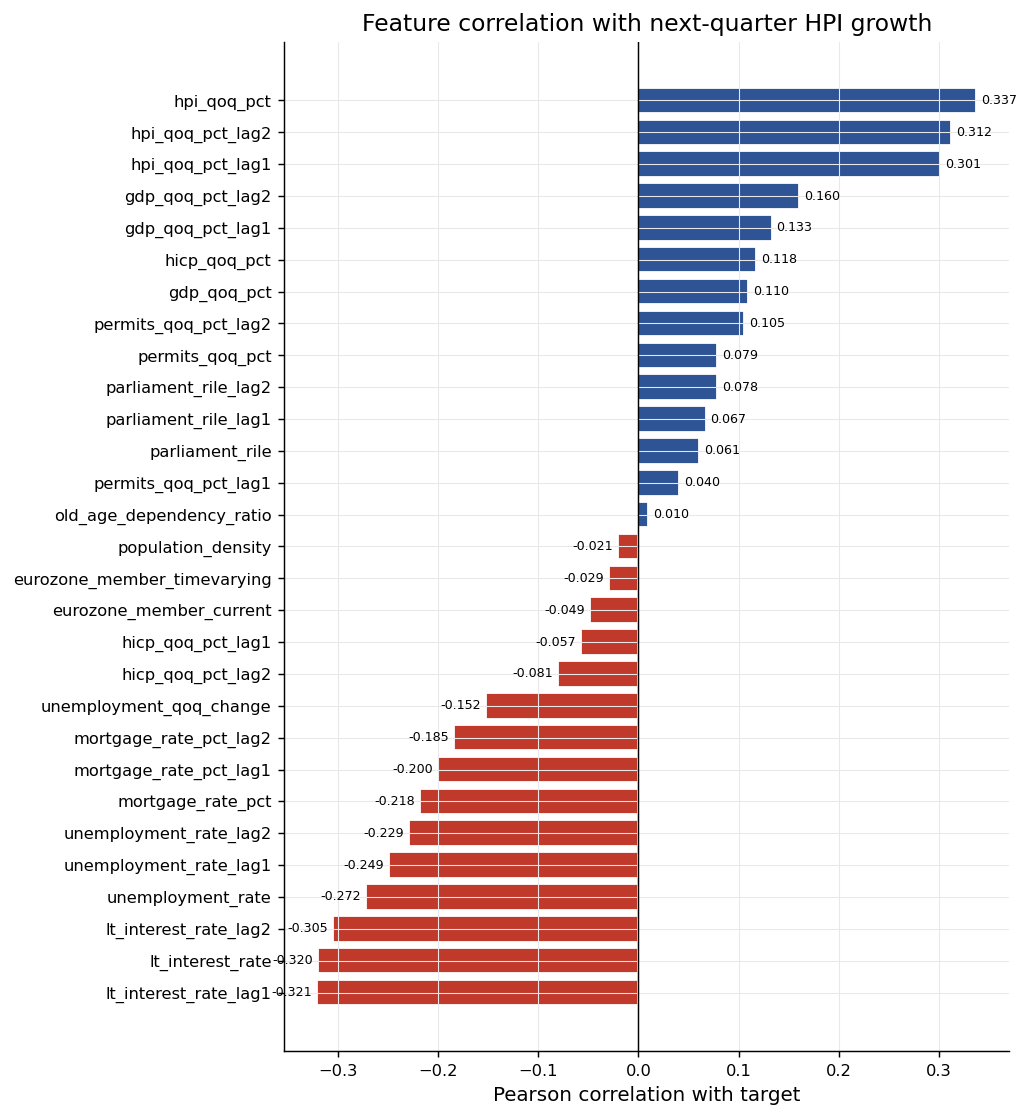


TOP 10 FEATURES BY | CORRELATION | WITH TARGET
hpi_qoq_pct               0.337
lt_interest_rate_lag1     0.321
lt_interest_rate          0.320
hpi_qoq_pct_lag2          0.312
lt_interest_rate_lag2     0.305
hpi_qoq_pct_lag1          0.301
unemployment_rate         0.272
unemployment_rate_lag1    0.249
unemployment_rate_lag2    0.229
mortgage_rate_pct         0.218


In [17]:
# 5.2  Feature–target correlation bar chart
# Include current period and lag features for the target correlation
all_feature_cols = [c for c in model_data.columns
                    if c not in ["country_code","country","quarter","year",
                                 "quarter_num","target_hpi_next_q",
                                 "hpi","hicp_q","gdp_index","building_permits_index"]]

target_corr = (model_data[all_feature_cols + ["target_hpi_next_q"]]
               .corr()["target_hpi_next_q"]
               .drop("target_hpi_next_q")
               .sort_values())

colors = [RED if v < 0 else ACCENT for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, max(6, len(target_corr) * 0.3)))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with target")
ax.set_title("Feature correlation with next-quarter HPI growth")

for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=7)

plt.tight_layout()
plt.show()

print("\nTOP 10 FEATURES BY | CORRELATION | WITH TARGET")
print(target_corr.abs().sort_values(ascending=False).head(10).round(3).to_string())


In [18]:
# 5.3  Multicollinearity check
feat_only = [c for c in feat_cols if c != "target_hpi_next_q"]
corr_feat = model_data[feat_only].corr()

high_corr_pairs = []
for i in range(len(corr_feat.columns)):
    for j in range(i+1, len(corr_feat.columns)):
        r = corr_feat.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append({
                "var_1": corr_feat.columns[i],
                "var_2": corr_feat.columns[j],
                "correlation": round(r, 3)
            })

print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7):")
if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df["abs_corr"] = high_corr_df["correlation"].abs()
    high_corr_df = high_corr_df.sort_values("abs_corr", ascending=False).drop(columns="abs_corr")
    print(high_corr_df.to_string())
else:
    print("No pairs found with |r| > 0.7")
    print("\nClosest pairs (top 10 by |r|):")
    pairs = []
    for i in range(len(corr_feat.columns)):
        for j in range(i+1, len(corr_feat.columns)):
            pairs.append({"var_1": corr_feat.columns[i],
                          "var_2": corr_feat.columns[j],
                          "correlation": round(corr_feat.iloc[i,j], 3)})
    top = pd.DataFrame(pairs)
    top["abs_corr"] = top["correlation"].abs()
    print(top.sort_values("abs_corr", ascending=False).drop(columns="abs_corr").head(10).to_string())
    

HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7):
No pairs found with |r| > 0.7

Closest pairs (top 10 by |r|):
                var_1                        var_2  correlation
51  mortgage_rate_pct             lt_interest_rate        0.665
40  unemployment_rate             lt_interest_rate        0.365
6         hpi_qoq_pct             lt_interest_rate       -0.338
3         hpi_qoq_pct            unemployment_rate       -0.304
57   lt_interest_rate  eurozone_member_timevarying       -0.287
56   lt_interest_rate              parliament_rile        0.255
5         hpi_qoq_pct            mortgage_rate_pct       -0.245
44  unemployment_rate           population_density       -0.227
0         hpi_qoq_pct                 hicp_qoq_pct        0.223
60    parliament_rile  eurozone_member_timevarying       -0.218


## 6. Cross-country Heterogeneity

Housing markets differ structurally across European countries. This section quantifies those differences and motivates the clustering component of the project — if countries behave very differently, a single pooled model may miss important structure.


In [19]:
# 6.1  Country-level averages for key variables
summary_vars = [
    "target_hpi_next_q", "hpi_qoq_pct", "gdp_qoq_pct",
    "unemployment_rate", "lt_interest_rate",
    "old_age_dependency_ratio", "population_density"
]
summary_vars = [c for c in summary_vars if c in model_data.columns]

country_means = model_data.groupby("country_code")[summary_vars].mean().round(2)
print("COUNTRY-LEVEL MEANS:")
print(country_means.sort_values("target_hpi_next_q", ascending=False).to_string())


COUNTRY-LEVEL MEANS:
              target_hpi_next_q  hpi_qoq_pct  gdp_qoq_pct  unemployment_rate  lt_interest_rate  old_age_dependency_ratio  population_density
country_code                                                                                                                                
HU                         2.15         2.06         0.57               6.27              5.26                     29.23              106.65
EE                         2.03         1.93         0.53               8.06              2.19                     30.80               30.74
LT                         1.63         1.50         0.80               9.58              2.71                     29.60               45.60
CZ                         1.48         1.39         0.46               4.29              2.53                     30.01              138.11
PT                         1.45         1.40         0.33              10.27              3.76                     34.80             

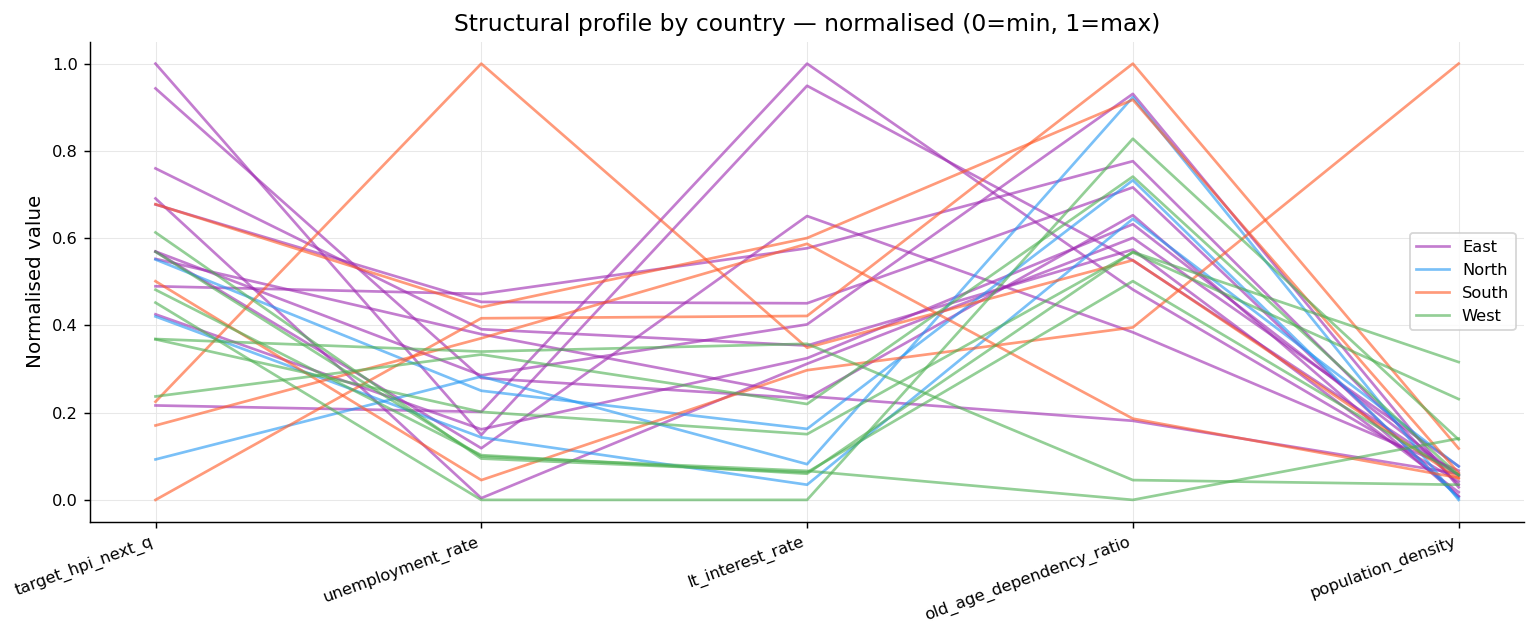

In [20]:
# 6.2  Radar / parallel coordinates — structural differences
# Normalise key structural variables (0-1) and plot as parallel coordinates
from pandas.plotting import parallel_coordinates

struct_vars = [
    "target_hpi_next_q", "unemployment_rate",
    "lt_interest_rate", "old_age_dependency_ratio", "population_density"
]
struct_vars = [c for c in struct_vars if c in model_data.columns]

country_struct = model_data.groupby("country_code")[struct_vars].mean()
country_struct_norm = (country_struct - country_struct.min()) / (country_struct.max() - country_struct.min())
country_struct_norm = country_struct_norm.reset_index()

# Simple geographic grouping for colour
geo_groups = {
    "North":  ["DK","FI","SE"],
    "West":   ["AT","BE","DE","FR","IE","LU","NL"],
    "South":  ["CY","EL","ES","IT","MT","PT"],
    "East":   ["BG","CZ","EE","HR","HU","LT","LV","PL","RO","SI","SK"]
}
country_struct_norm["region"] = country_struct_norm["country_code"].map(
    {cc: reg for reg, ccs in geo_groups.items() for cc in ccs}
).fillna("Other")

fig, ax = plt.subplots(figsize=(12, 5))
region_colors = {"North":"#2196F3","West":"#4CAF50","South":"#FF5722","East":"#9C27B0","Other":"#9E9E9E"}
for region, group in country_struct_norm.groupby("region"):
    for _, row in group.iterrows():
        ax.plot(struct_vars, row[struct_vars].values,
                color=region_colors[region], alpha=0.6, linewidth=1.5,
                label=region)

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=9)
ax.set_title("Structural profile by country — normalised (0=min, 1=max)")
ax.set_ylabel("Normalised value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


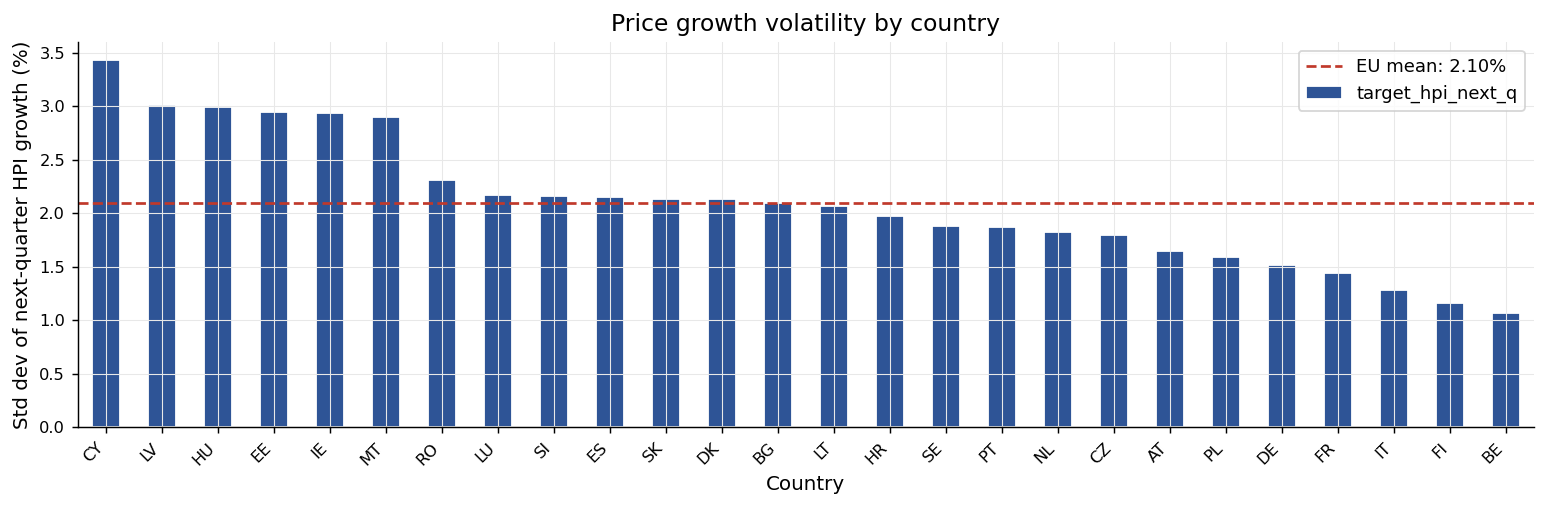

MOST VOLATILE MARKETS: 
country_code
CY    3.428
LV    3.011
HU    2.988
EE    2.949
IE    2.936
MT    2.896
RO    2.312
LU    2.173
SI    2.163
ES    2.151

MOST STABLE MARKETS: 
country_code
PT    1.874
NL    1.826
CZ    1.800
AT    1.647
PL    1.594
DE    1.519
FR    1.440
IT    1.280
FI    1.160
BE    1.066


In [21]:
# 6.3  Volatility by country
country_std = (model_data.groupby("country_code")["target_hpi_next_q"]
               .std().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 4))
country_std.plot(kind="bar", ax=ax, color=ACCENT, edgecolor="white")
ax.set_xlabel("Country")
ax.set_ylabel("Std dev of next-quarter HPI growth (%)")
ax.set_title("Price growth volatility by country")
ax.axhline(country_std.mean(), color=RED, linestyle="--",
           linewidth=1.5, label=f"EU mean: {country_std.mean():.2f}%")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("MOST VOLATILE MARKETS: ")
print(country_std.head(10).round(3).to_string())
print("\nMOST STABLE MARKETS: ")
print(country_std.tail(10).round(3).to_string())


STRUCTURAL OUTLIER SUMMARY BY COUNTRY
country_code  population_density  old_age_dependency_ratio  parliament_rile  avg_target_growth  target_volatility  n_structural_outlier_flags
          HU               107.1                      29.0            20.76               2.15               2.99                           2
          LU               239.8                      20.7           -13.67               1.22               2.17                           2
          BE               377.3                      29.5            -7.66               0.78               1.07                           1
          CY                95.7                      23.8            -1.32               0.35               3.43                           1
          IE                71.9                      21.5           -20.41               0.78               2.94                           1
          IT               200.6                      35.8            -0.58              -0.02               1

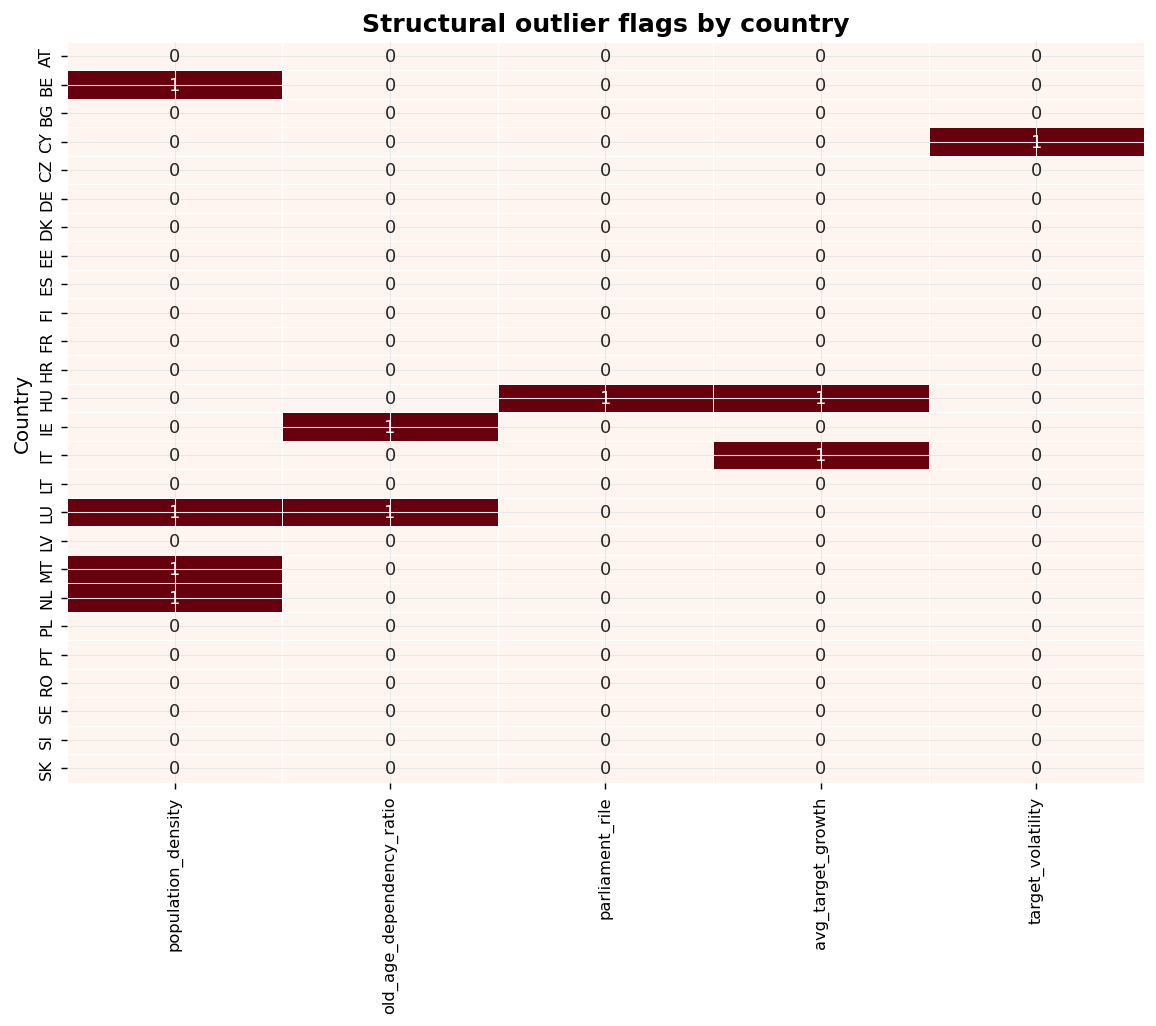

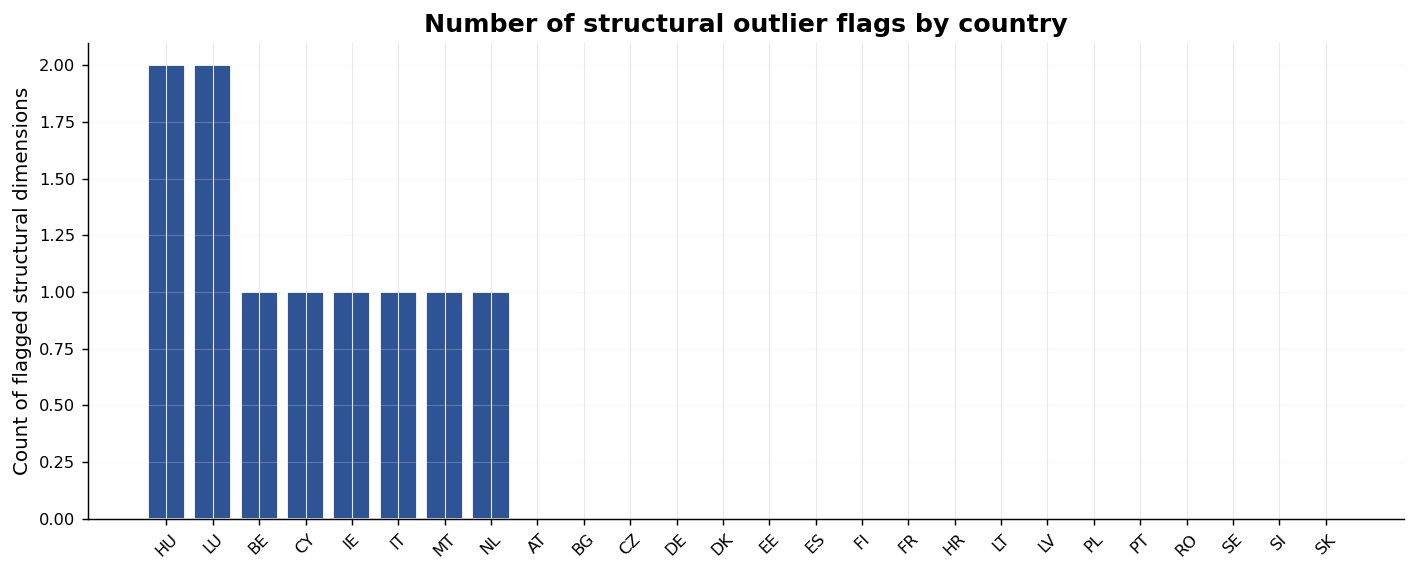

In [22]:
## 6.4 Structural outliers by country
# To complement the country-wise outlier checks over time, we also identify structural outliers at the country level. 
# Here, the goal is not to detect unusual quarters, but countries whose long-run structural profile differs markedly from the rest of the panel.
# We focus on slow-moving and structural characteristics such as population density, old-age dependency, and parliament ideology, and add average target growth and target volatility as contextual cross-country indicators. 
# Outliers are identified using an across-country IQR rule and interpreted descriptively rather than as observations to remove.

structural_profile = (
    model_data.groupby("country_code")
    .agg(
        population_density=("population_density", "median"),
        old_age_dependency_ratio=("old_age_dependency_ratio", "median"),
        parliament_rile=("parliament_rile", "median"),
        avg_target_growth=("target_hpi_next_q", "mean"),
        target_volatility=("target_hpi_next_q", "std")
    )
    .reset_index()
)

structural_vars = [
    "population_density",
    "old_age_dependency_ratio",
    "parliament_rile",
    "avg_target_growth",
    "target_volatility"
]

all_structural_flags = []

for var in structural_vars:
    q1 = structural_profile[var].quantile(0.25)
    q3 = structural_profile[var].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    structural_profile[f"{var}_lower"] = lower
    structural_profile[f"{var}_upper"] = upper
    structural_profile[f"{var}_outlier"] = (
        (structural_profile[var] < lower) |
        (structural_profile[var] > upper)
    )

    flagged = structural_profile.loc[
        structural_profile[f"{var}_outlier"],
        ["country_code", var]
    ].copy()
    flagged["variable"] = var
    all_structural_flags.append(flagged)

structural_flags = pd.concat(all_structural_flags, ignore_index=True)

# Count how many structural dimensions each country is flagged on
flag_cols = [f"{v}_outlier" for v in structural_vars]
structural_profile["n_structural_outlier_flags"] = structural_profile[flag_cols].sum(axis=1)

# Compact summary
summary_cols = ["country_code"] + structural_vars + ["n_structural_outlier_flags"]
structural_summary = structural_profile[summary_cols].sort_values(
    ["n_structural_outlier_flags", "country_code"],
    ascending=[False, True]
)

print("STRUCTURAL OUTLIER SUMMARY BY COUNTRY")
print(structural_summary.round(2).to_string(index=False))

print("\nFLAGGED STRUCTURAL OUTLIERS")
if len(structural_flags) > 0:
    print(structural_flags.sort_values(["variable", "country_code"]).round(2).to_string(index=False))
else:
    print("No structural outliers flagged under the IQR rule.")

# Heatmap of flags
flag_matrix = structural_profile.set_index("country_code")[flag_cols].astype(int)
flag_matrix.columns = structural_vars

plt.figure(figsize=(9, 8))
sns.heatmap(flag_matrix, annot=True, fmt="d", cmap="Reds", cbar=False, linewidths=0.5)
plt.title("Structural outlier flags by country", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Bar chart: number of structural outlier flags per country
plot_df = structural_summary.sort_values(
    ["n_structural_outlier_flags", "country_code"],
    ascending=[False, True]
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(
    plot_df["country_code"],
    plot_df["n_structural_outlier_flags"],
    color=ACCENT,
    edgecolor="white"
)
ax.set_title("Number of structural outlier flags by country", fontsize=14, weight="bold")
ax.set_ylabel("Count of flagged structural dimensions")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The structural outlier analysis shows that unusual country profiles are concentrated in a small subset of markets rather than broadly spread across the panel. Luxembourg and Hungary stand out most strongly, each being flagged on two structural dimensions. Population density outliers are concentrated in Malta, the Netherlands, Belgium, and Luxembourg, while Ireland and Luxembourg appear as unusually young in old-age dependency terms. Hungary is flagged both for unusually high parliament ideology scores and high average target growth, Italy for exceptionally weak average target growth, and Cyprus for unusually high target volatility. Overall, the results confirm that structural heterogeneity is driven by a few clearly distinct country profiles rather than by diffuse differences across all markets.

## 7. Autocorrelation and Time Series Structure

Housing prices show strong temporal persistence — last quarter's growth is the best single predictor of next quarter's growth. This section verifies that structure is present in our data, and checks whether our lag features are capturing it correctly.


In [24]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 9.3 MB/s eta 0:00:01
   ------------ --------------------------- 2.9/9.6 MB 8.8 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.6 MB 9.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 9.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 8.9 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [

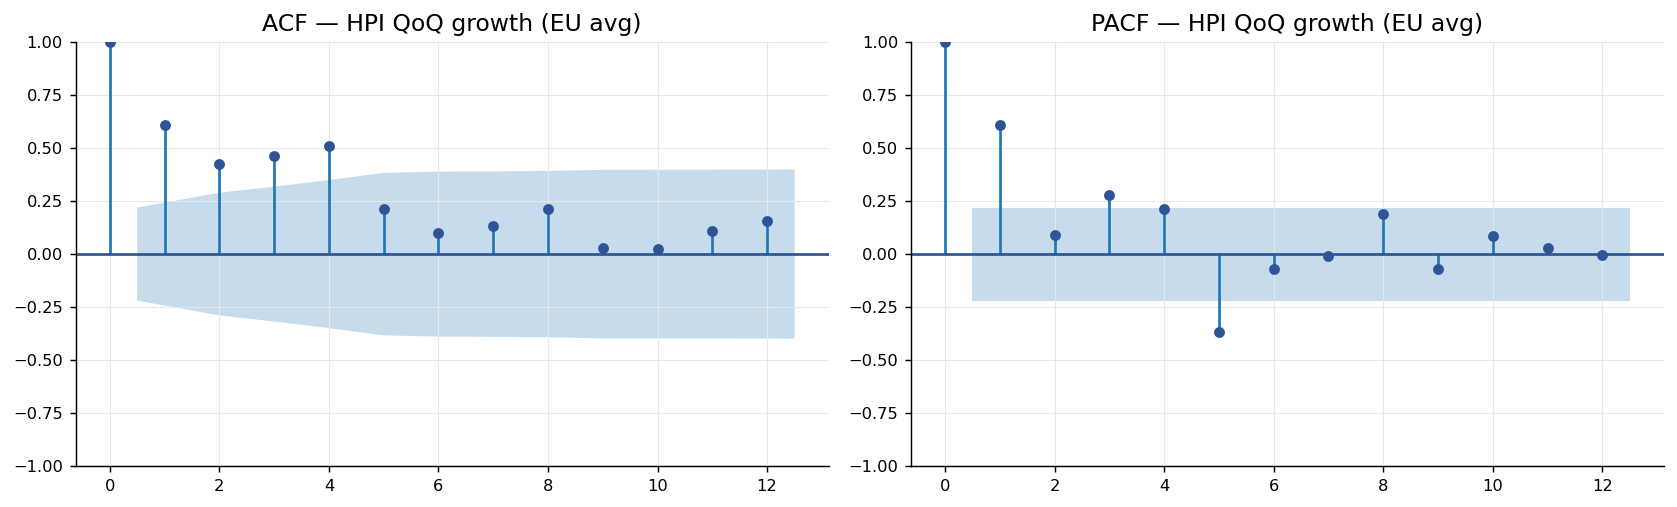

Autocorrelations at key lags:
  lag-1: 0.632
  lag-2: 0.445
  lag-3: 0.490
  lag-4: 0.548


In [25]:
# 7.1  Autocorrelation of HPI growth (EU average)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

eu_hpi = model_data.groupby("quarter")["hpi_qoq_pct"].mean().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(eu_hpi, lags=12, ax=axes[0], color=ACCENT, title="ACF — HPI QoQ growth (EU avg)")
plot_pacf(eu_hpi, lags=12, ax=axes[1], color=ACCENT, title="PACF — HPI QoQ growth (EU avg)")
plt.tight_layout()
plt.show()

print("Autocorrelations at key lags:")
for lag in [1, 2, 3, 4]:
    r = eu_hpi.autocorr(lag=lag)
    print(f"  lag-{lag}: {r:.3f}")


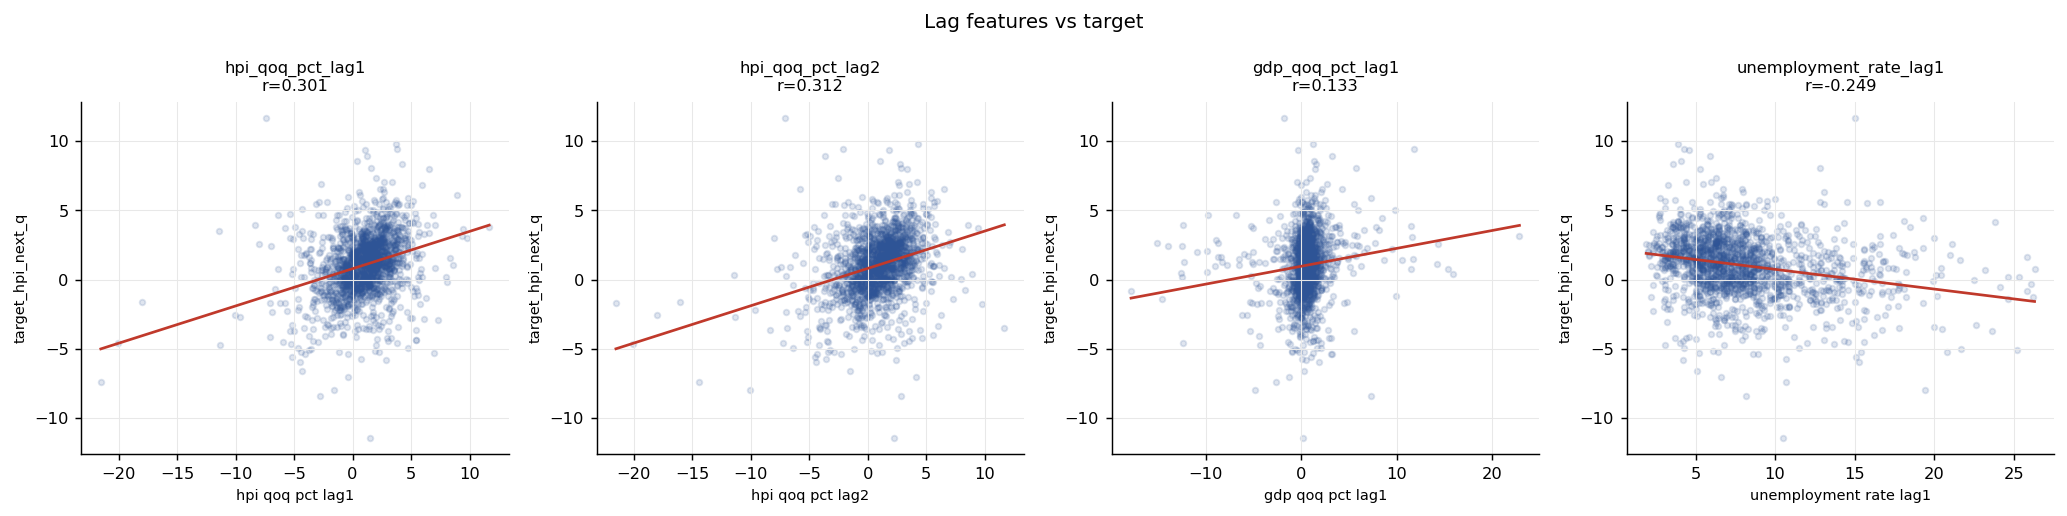

In [26]:
# 7.2  Lag scatter plots: target vs lag-1 and lag-2
lag_cols_check = [c for c in ["hpi_qoq_pct_lag1","hpi_qoq_pct_lag2",
                               "gdp_qoq_pct_lag1","unemployment_rate_lag1"]
                  if c in model_data.columns]

fig, axes = plt.subplots(1, len(lag_cols_check), figsize=(4*len(lag_cols_check), 4))
if len(lag_cols_check) == 1:
    axes = [axes]

for ax, col in zip(axes, lag_cols_check):
    sub = model_data[[col, "target_hpi_next_q"]].dropna()
    ax.scatter(sub[col], sub["target_hpi_next_q"],
               alpha=0.15, s=10, color=ACCENT)
    # Regression line
    m, b = np.polyfit(sub[col], sub["target_hpi_next_q"], 1)
    x_range = np.linspace(sub[col].min(), sub[col].max(), 100)
    ax.plot(x_range, m*x_range+b, color=RED, linewidth=1.5)
    r = sub[[col,"target_hpi_next_q"]].corr().iloc[0,1]
    ax.set_title(f"{col}\nr={r:.3f}", fontsize=9)
    ax.set_xlabel(col.replace("_"," "), fontsize=8)
    ax.set_ylabel("target_hpi_next_q", fontsize=8)

plt.suptitle("Lag features vs target", fontsize=11)
plt.tight_layout()
plt.show()


## 8. Train / Test Split Analysis

Because this is a time series forecasting problem, we cannot use random cross-validation, that would leak future information into the past. We use a temporal split: train on early data, test on the most recent period. This section helps us choose the split point.


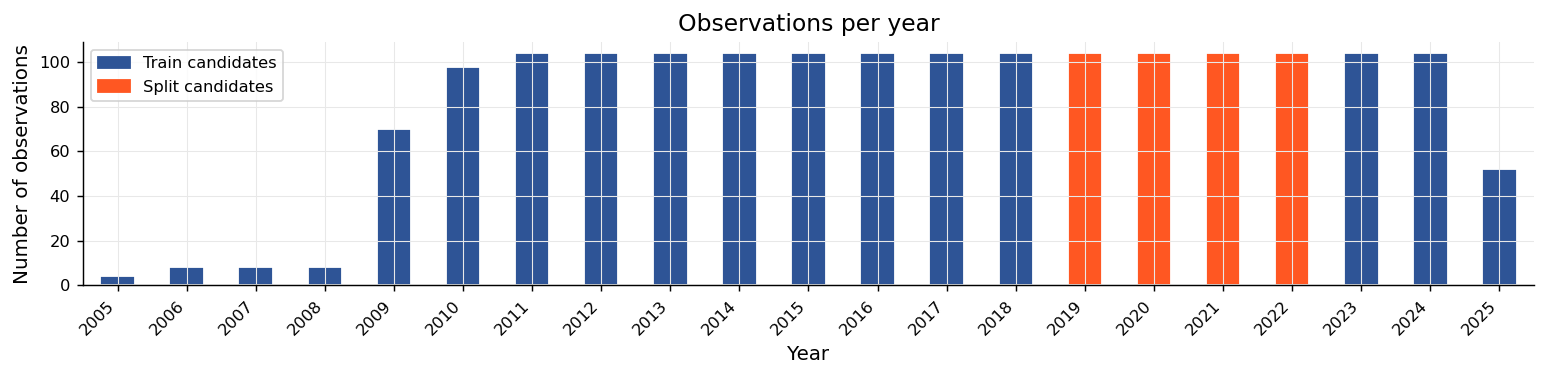

OBSERVATIONS BY YEAR: 
year
2005      4
2006      8
2007      8
2008      8
2009     70
2010     98
2011    104
2012    104
2013    104
2014    104
2015    104
2016    104
2017    104
2018    104
2019    104
2020    104
2021    104
2022    104
2023    104
2024    104
2025     52

Total: 1704
Split at 2019: train=1028, test=676 (39.7% test)
Split at 2020: train=1132, test=572 (33.6% test)
Split at 2021: train=1236, test=468 (27.5% test)
Split at 2022: train=1340, test=364 (21.4% test)


In [27]:
# 8.1  Observation count by year
obs_by_year = model_data.groupby("year").size()

fig, ax = plt.subplots(figsize=(12, 3))
obs_by_year.plot(kind="bar", ax=ax, color=ACCENT, edgecolor="white")
ax.set_xlabel("Year")
ax.set_ylabel("Number of observations")
ax.set_title("Observations per year")
plt.xticks(rotation=45, ha="right")

# Highlight candidate split years
for split_year in [2019, 2020, 2021, 2022]:
    if split_year in obs_by_year.index:
        idx = list(obs_by_year.index).index(split_year)
        ax.get_children()[idx].set_color("#FF5722")
        ax.get_children()[idx].set_edgecolor("white")

ax.legend(handles=[
    plt.Rectangle((0,0),1,1,color=ACCENT, label="Train candidates"),
    plt.Rectangle((0,0),1,1,color="#FF5722", label="Split candidates")
], fontsize=9)
plt.tight_layout()
plt.show()

print("OBSERVATIONS BY YEAR: ")
print(obs_by_year.to_string())
print(f"\nTotal: {obs_by_year.sum()}")

for split_year in [2019, 2020, 2021, 2022]:
    n_train = (model_data["year"] < split_year).sum()
    n_test  = (model_data["year"] >= split_year).sum()
    pct     = n_test / len(model_data) * 100
    print(f"Split at {split_year}: train={n_train}, test={n_test} ({pct:.1f}% test)")


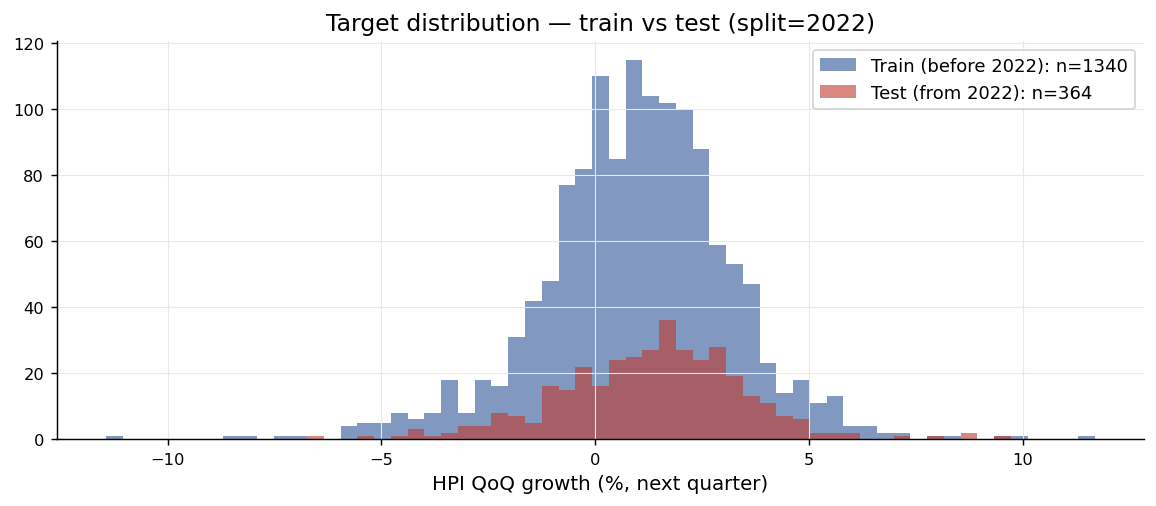

Train mean: 0.956% | std: 2.224%
Test mean:  1.325%  | std: 2.196%
Distribution shift: 0.369% difference in mean


In [28]:
# 8.2  Target distribution: train vs test (for candidate split 2022)
SPLIT_YEAR = 2022

train = model_data[model_data["year"] < SPLIT_YEAR]["target_hpi_next_q"].dropna()
test  = model_data[model_data["year"] >= SPLIT_YEAR]["target_hpi_next_q"].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(
    model_data["target_hpi_next_q"].min(),
    model_data["target_hpi_next_q"].max(), 60)
ax.hist(train, bins=bins, alpha=0.6, color=ACCENT, label=f"Train (before {SPLIT_YEAR}): n={len(train)}")
ax.hist(test,  bins=bins, alpha=0.6, color=RED,   label=f"Test (from {SPLIT_YEAR}): n={len(test)}")
ax.set_xlabel("HPI QoQ growth (%, next quarter)")
ax.set_title(f"Target distribution — train vs test (split={SPLIT_YEAR})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Train mean: {train.mean():.3f}% | std: {train.std():.3f}%")
print(f"Test mean:  {test.mean():.3f}%  | std: {test.std():.3f}%")
print(f"Distribution shift: {abs(train.mean()-test.mean()):.3f}% difference in mean")


## 9. Pre-Modelling Checklist

**Complete this section before starting the ML notebook.** This is a structured summary of everything the EDA has revealed that must be accounted for in the modelling decisions.


In [29]:
# 9.1  Automated summary statistics
print("PRE-MODELLING CHECKLIST — AUTO SUMMARY")

# Target
t = model_data["target_hpi_next_q"].dropna()
print(f"\nTARGET: target_hpi_next_q")
print(f"  Mean:     {t.mean():.3f}%")
print(f"  Std:      {t.std():.3f}%")
print(f"  Skewness: {t.skew():.3f}  {'⚠ moderate skew' if abs(t.skew())>1 else 'OK'}")
print(f"  Kurtosis: {t.kurtosis():.3f}  {'⚠ heavy tails' if t.kurtosis()>3 else 'OK'}")
print(f"  % positive: {(t>0).mean()*100:.1f}%")

# Missing
print(f"\nMISSING VALUES (in model_data):")
miss = model_data.isnull().mean() * 100
miss = miss[miss > 0].sort_values(ascending=False)
for col, pct in miss.items():
    print(f"  {col:<35} {pct:.1f}%")

# Top correlations with target
all_num = model_data.select_dtypes(include=np.number).drop(
    columns=["year","quarter_num","eurozone_member_current"], errors="ignore")
corr_target = all_num.corr()["target_hpi_next_q"].drop("target_hpi_next_q").abs().sort_values(ascending=False)
print(f"\nTOP 5 FEATURES BY |CORRELATION| WITH TARGET:")
for feat, r in corr_target.head(5).items():
    print(f"  {feat:<40} r={r:.3f}")

# Dataset split
SPLIT_YEAR = 2022
n_train = (model_data["year"] < SPLIT_YEAR).sum()
n_test  = (model_data["year"] >= SPLIT_YEAR).sum()
print(f"\nSUGGESTED TRAIN/TEST SPLIT: year < {SPLIT_YEAR}")
print(f"  Train: {n_train} rows")
print(f"  Test:  {n_test} rows ({n_test/len(model_data)*100:.1f}%)")


PRE-MODELLING CHECKLIST — AUTO SUMMARY

TARGET: target_hpi_next_q
  Mean:     1.035%
  Std:      2.222%
  Skewness: -0.243  OK
  Kurtosis: 1.939  OK
  % positive: 70.7%

MISSING VALUES (in model_data):
  mortgage_rate_pct_lag2              33.5%
  mortgage_rate_pct_lag1              33.1%
  mortgage_rate_pct                   32.9%
  old_age_dependency_ratio            29.8%
  population_density                  23.7%
  parliament_rile_lag2                5.4%
  parliament_rile_lag1                4.8%
  parliament_rile                     4.1%
  lt_interest_rate_lag2               3.1%
  lt_interest_rate_lag1               2.6%
  lt_interest_rate                    2.6%
  unemployment_rate_lag2              1.5%
  unemployment_qoq_change             1.5%
  permits_qoq_pct_lag2                0.4%
  gdp_qoq_pct_lag2                    0.4%
  hicp_qoq_pct_lag2                   0.4%
  hpi_qoq_pct_lag2                    0.4%

TOP 5 FEATURES BY |CORRELATION| WITH TARGET:
  hpi_qoq_pct   